# Cars Price Prediction in Poland

The automotive market in Poland is dynamic and highly diverse, with thousands of new and used vehicles being listed for sale every day. Prices of cars vary significantly depending on factors such as brand, model, production year, mileage, engine type, power, transmission, equipment level, and overall market trends. 

For both buyers and sellers, accurately estimating the fair market value of a vehicle can be challenging and often relies on subjective assessments or incomplete information.

The goal of this project is to build a machine learning model that predicts car prices in the Polish market based on publicly available vehicle listings. By analyzing historical data and identifying key features that influence pricing, the project aims to deliver a tool capable of generating reliable price estimates.

## Libraries and Data Loading

In [115]:
# Loading libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.ticker as ticker
import seaborn as sns
import optuna
import joblib
import requests
import xgboost as xgb
import os
import tempfile
from huggingface_hub import HfApi, login
from category_encoders import TargetEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, KFold, learning_curve, GridSearchCV, RandomizedSearchCV
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder, PowerTransformer, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error,  mean_absolute_percentage_error


In [116]:
# Loading the dataset

cars_data = pd.read_csv('../data/Car_sale_ads.csv')

In [117]:
cars_data.head()

,Index,Price,Currency,Condition,Vehicle_brand,Vehicle_model,Vehicle_version,Vehicle_generation,Production_year,Mileage_km,...,Transmission,Type,Doors_number,Colour,Origin_country,First_owner,First_registration_date,Offer_publication_date,Offer_location,Features
0,0,86200,PLN,New,Abarth,595,NaN,NaN,2021,1.0,...,Manual,small_cars,3.0,gray,NaN,NaN,NaN,04/05/2021,"ul. Jubilerska 6 - 04-190 Warszawa, Mazowiecki...",[]
1,1,43500,PLN,Used,Abarth,Other,NaN,NaN,1974,59000.0,...,Manual,coupe,2.0,silver,NaN,NaN,NaN,03/05/2021,"kanonierska12 - 04-425 Warszawa, Rembertów (Po...",[]
2,2,44900,PLN,Used,Abarth,500,NaN,NaN,2018,52000.0,...,Automatic,small_cars,3.0,silver,NaN,NaN,NaN,03/05/2021,"Warszawa, Mazowieckie, Białołęka","['ABS', 'Electric front windows', 'Drivers air..."
3,3,39900,PLN,Used,Abarth,500,NaN,NaN,2012,29000.0,...,Manual,small_cars,3.0,gray,NaN,NaN,NaN,30/04/2021,"Jaworzno, Śląskie","['ABS', 'Electric front windows', 'Drivers air..."
4,4,97900,PLN,New,Abarth,595,NaN,NaN,2021,600.0,...,Manual,small_cars,3.0,blue,NaN,NaN,NaN,30/04/2021,"ul. Gorzysława 9 - 61-057 Poznań, Nowe Miasto ...","['ABS', 'Electrically adjustable mirrors', 'Pa..."


## Data Preprocessing

In [118]:
# Getting some info about dataset

cars_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208304 entries, 0 to 208303
Data columns (total 25 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Index                    208304 non-null  int64  
 1   Price                    208304 non-null  int64  
 2   Currency                 208304 non-null  object 
 3   Condition                208304 non-null  object 
 4   Vehicle_brand            208304 non-null  object 
 5   Vehicle_model            208304 non-null  object 
 6   Vehicle_version          138082 non-null  object 
 7   Vehicle_generation       147860 non-null  object 
 8   Production_year          208304 non-null  int64  
 9   Mileage_km               207321 non-null  float64
 10  Power_HP                 207661 non-null  float64
 11  Displacement_cm3         206338 non-null  float64
 12  Fuel_type                208304 non-null  object 
 13  CO2_emissions            94047 non-null   float64
 14  Driv

In [119]:
# Displaying the description without scientific notation

cars_data.describe().applymap(lambda x: f"{x:.2f}")

C:\Users\Przemek\AppData\Local\Temp\ipykernel_10040\2643292621.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  cars_data.describe().applymap(lambda x: f"{x:.2f}")


,Index,Price,Production_year,Mileage_km,Power_HP,Displacement_cm3,CO2_emissions,Doors_number
count,208304.00,208304.00,208304.00,207321.00,207661.00,206338.00,94047.00,206817.00
mean,104151.50,63053.83,2012.10,150276.76,151.84,1882.57,319156.38,4.64
std,60132.33,86659.67,7.00,2937446.81,77.68,729.61,72913958.71,0.77
min,0.00,500.00,1915.00,1.00,1.00,400.00,1.00,1.00
25%,52075.75,17800.00,2008.00,53000.00,105.00,1461.00,120.00,5.00
50%,104151.50,35700.00,2013.00,144566.00,136.00,1798.00,140.00,5.00
75%,156227.25,75990.00,2017.00,206000.00,172.00,1997.00,164.00,5.00
max,208303.00,6999000.00,2021.00,1111111111.00,1398.00,8400.00,20000000000.00,55.00


In [120]:
cars_data.columns

Index(['Index', 'Price', 'Currency', 'Condition', 'Vehicle_brand',
       'Vehicle_model', 'Vehicle_version', 'Vehicle_generation',
       'Production_year', 'Mileage_km', 'Power_HP', 'Displacement_cm3',
       'Fuel_type', 'CO2_emissions', 'Drive', 'Transmission', 'Type',
       'Doors_number', 'Colour', 'Origin_country', 'First_owner',
       'First_registration_date', 'Offer_publication_date', 'Offer_location',
       'Features'],
      dtype='object')

In [121]:
# How many missing values are in the dataset

cars_data.isna().sum()

Index                           0
Price                           0
Currency                        0
Condition                       0
Vehicle_brand                   0
Vehicle_model                   0
Vehicle_version             70222
Vehicle_generation          60444
Production_year                 0
Mileage_km                    983
Power_HP                      643
Displacement_cm3             1966
Fuel_type                       0
CO2_emissions              114257
Drive                       15076
Transmission                  479
Type                            0
Doors_number                 1487
Colour                          0
Origin_country              89992
First_owner                143210
First_registration_date    121859
Offer_publication_date          0
Offer_location                  0
Features                        0
dtype: int64

In [122]:
# Checking amount of duplicates in 'Currency' column

print((cars_data['Currency'] != 'PLN').sum())

# Expolring is there some other curriencies

print(cars_data.loc[cars_data['Currency'] != 'PLN', 'Currency'].unique())

270
['EUR']


Since prices are provided in currencies other than PLN (EUR), we convert them to PLN using the current exchange rate from the NBP API.

In [123]:
def get_current_eur_pln_rate():
    url = "http://api.nbp.pl/api/exchangerates/rates/a/eur/?format=json"
    
    try:
        response = requests.get(url, timeout=5) 
        response.raise_for_status()
        data = response.json()
        
        rate = data['rates'][0]['mid']
        print(f"Current exchange rate was loaded from NBP: {rate}")
        return rate
        
    except Exception as e:
        print(f"There was a failure with loading exchange rate ({e}). Default value was taken.")
        return 4.30
    
EUR_to_PLN = get_current_eur_pln_rate()

cars_data['price_PLN'] = cars_data.apply(
    lambda row: row['Price'] * EUR_to_PLN if row['Currency'] == 'EUR' else row['Price'],
    axis=1
)

Current exchange rate was loaded from NBP: 4.2782


As all prices are now in PLN, the old Price and Currency columns are no longer needed and can be removed; price_PLN contains the current values.

In [124]:
price_cols = ['Currency', 'Price']

cars_data_cleaned = cars_data.drop(columns=price_cols)

Some columns are not useful for future price prediction models and can therefore be removed:

- CO2_emissions – This variable is not a key factor influencing car prices in the Polish market and is unlikely to significantly improve model performance.

- First_registration – The Production_year variable is more informative. Since the production year is known, the vehicle’s age can be derived directly, making the first registration date redundant.

- Vehicle_version – The dataset already includes more objective and measurable characteristics such as Power_HP and Displacement_cm3, which better capture technical differences between vehicles.

Moreover, these features contain a substantial number of missing values. Imputing them using the median or mode could introduce noise and potentially mislead the model rather than improve its predictive performance.

In [125]:
cols_to_drop = ['CO2_emissions', 'First_registration_date', 'Vehicle_version']

cars_data_cleaned = cars_data_cleaned.drop(columns=cols_to_drop)

It is a good practice to check for duplicate rows in the dataset and remove them. This ensures that the dataset is clean and that any analyses or visualizations, such as charts, are more reliable and not biased by repeated entries.

In [126]:
duplicates_count = cars_data_cleaned.drop(columns=['Index']).duplicated().sum()

print(f"Number of founded duplicates: {duplicates_count}")
print(f"Duplicates percentage: {(duplicates_count / len(cars_data_cleaned)) * 100:.2f}%")

Number of founded duplicates: 1610
Duplicates percentage: 0.77%


We will check all columns to see if there are duplicate rows, ignoring the index column since it is unique by definition. This ensures that any identical rows across the other features are detected and can be handled appropriately.

In [127]:
cols_to_check = cars_data_cleaned.columns.difference(['Index'])

cars_data_cleaned = cars_data_cleaned.drop_duplicates(subset=cols_to_check, keep='first')

In the First_owner column, there are surprisingly over 140,000 missing values. However, this variable should still be considered, as cars sold by their first owner often achieve higher prices because they are perceived as a safer and more reliable purchase.

In [128]:
print(cars_data_cleaned.loc[cars_data_cleaned['First_owner'] != 'Yes', 'First_owner'].unique())

[nan]


After examining the values in the First_owner column, we can conclude that the missing values (NaN) most likely represent “No”, as only two possible states appear in this column: “Yes” and missing values.

From the buyer’s perspective, if a seller did not explicitly mark the offer as “first owner”, it is reasonable to assume that the vehicle has had more than one previous owner.

Therefore, missing values can be safely replaced with “No”.

This assumption is based on marketplace behavior, where sellers typically highlight “first owner” status as a selling advantage.

In [129]:
cars_data_cleaned['First_owner'] = cars_data_cleaned['First_owner'].apply(lambda x: 1 if x == 'Yes' else 0)

There are nearly 90,000 missing values in the Origin_country column. This variable is problematic because the country of origin is not always clearly defined. In many cases, vehicles are manufactured in factories located outside the brand’s home country. Additionally, private sellers may not provide this information, making it impossible to reliably determine the true country of origin.

To avoid introducing noise through incorrect imputation, the missing values will be replaced with "Unknown". This approach allows the model to treat these observations as a separate category without making unjustified assumptions.

In [130]:
cars_data_cleaned['Origin_country'] = cars_data_cleaned['Origin_country'].fillna('Unknown')

Some features need to be converted to more appropriate data types to improve efficiency and readability in the future EDA section.

For example, doors_number should be converted to an integer type, as vehicles cannot have a fractional number of doors.

Similarly, Displacement_cm3, Power_HP and Mileage_km should also be stored as an integer, since those features are always expressed as a whole number in the Polish car market.

In [131]:
cols_to_int = ['Doors_number', 'Mileage_km', 'Power_HP', 'Displacement_cm3']
for col in cols_to_int:
    cars_data_cleaned[col] = cars_data_cleaned[col].astype('Int64')

Some features are stored as the object data type, which consumes more memory than necessary. Converting these variables to the category type is a better approach, as it reduces memory usage and improves computational efficiency.

Additionally, using the category type can be beneficial for models such as LightGBM and CatBoost, which are designed to handle categorical features efficiently and can leverage this information during training.

In [132]:
cat_cols = ['Condition', 'Fuel_type', 'Transmission', 'Drive', 'Type', 'Colour', 'Vehicle_brand']
for col in cat_cols:
    cars_data_cleaned[col] = cars_data_cleaned[col].astype('category')

The offer publication date is converted to a datetime format to simplify time-based visualizations and allow the extraction of additional temporal features (e.g., year, month, or season).

In [133]:
cars_data_cleaned['Offer_publication_date'] = pd.to_datetime(
    cars_data['Offer_publication_date'],
    format='%d/%m/%Y'
)

Now, we perform string cleaning, which is a crucial step for ensuring that models can correctly interpret categorical features.

We start with basic cleaning, such as normalizing all text to lowercase, and then apply more advanced cleaning to specific columns that contain categorical string data. This helps eliminate inconsistencies, typos, and variations that could otherwise introduce noise into the model.

In [134]:
text_cols = ['Vehicle_brand', 'Vehicle_model', 'Fuel_type', 'Transmission', 'Drive', 'Type', 'Colour', 'Origin_country', 'Condition']

for col in text_cols:
    cars_data_cleaned[col] = cars_data_cleaned[col].str.strip().str.lower()

In [135]:
cars_data_cleaned['Features'] = cars_data_cleaned['Features'].str.replace(r"[\[\]']", "", regex=True).str.lower()

---

In the data preprocessing section, the dataset was prepared for the visualization stage. The following steps were performed:

- Currency normalization: All prices were converted to the same currency (PLN) using the current exchange rate from the NBP API.

- Dimensionality reduction: Columns that were irrelevant for predicting car prices or contained a large number of missing values were dropped.

- Removing duplicates: Approximately 0.77% of the dataset consisted of duplicate rows, which were detected and removed.

- Text normalization: Categorical columns were cleaned by converting text to lowercase and removing extra spaces.

- Adjusting variable types: Some columns were converted to more appropriate data types to reduce memory usage and improve the efficiency of future models.

## Exploratory Data Analysis

#### Section I - Understanding the Target

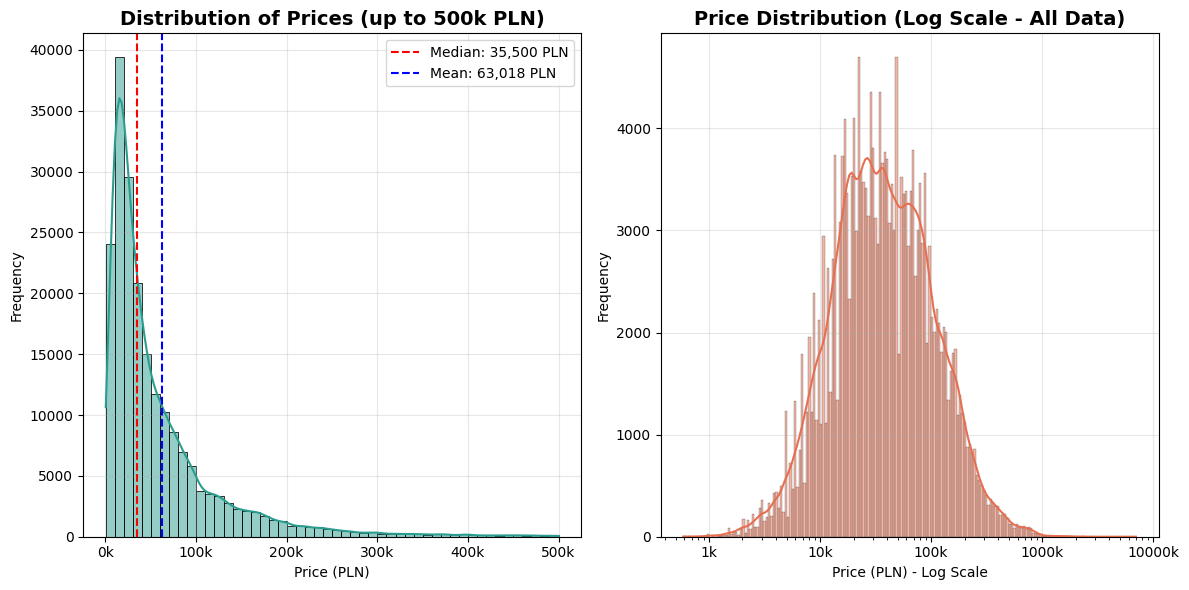

In [136]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

market_limit = 500000
sns.histplot(cars_data_cleaned[cars_data_cleaned['price_PLN'] <= market_limit]['price_PLN'], 
             kde=True, ax=axes[0], color='#2a9d8f', bins=50)

axes[0].set_title(f'Distribution of Prices (up to {int(market_limit/1000)}k PLN)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Price (PLN)')
axes[0].set_ylabel('Frequency')
axes[0].grid(True, alpha=0.3)
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))

sns.histplot(cars_data_cleaned['price_PLN'], 
             kde=True, ax=axes[1], color='#e76f51', log_scale=True)

axes[1].set_title('Price Distribution (Log Scale - All Data)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Price (PLN) - Log Scale')
axes[1].set_ylabel('Frequency')
axes[1].grid(True, alpha=0.3)
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))

median_price = cars_data_cleaned['price_PLN'].median()
mean_price = cars_data_cleaned['price_PLN'].mean()

axes[0].axvline(median_price, color='red', linestyle='--', label=f'Median: {int(median_price):,} PLN')
axes[0].axvline(mean_price, color='blue', linestyle='--', label=f'Mean: {int(mean_price):,} PLN')
axes[0].legend()

plt.tight_layout()
plt.savefig('../images/eda_price_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

##### Price Distribtion

The left chart displays a highly right-skewed distribution, where most observations fall between 0 and 100,000 PLN, with a median of approximately 35,500 PLN.

The mean value is nearly twice as high as the median, indicating the presence of high-priced premium vehicles that pull the average upward. This confirms that the distribution is positively skewed. In such cases, the median provides a more representative measure of the typical car price than the mean.

The right chart shows that applying a logarithmic transformation significantly reduces skewness, making the distribution more symmetrical and closer to a normal distribution.

This suggests that using a log-transformed target variable may improve model performance — particularly for regression algorithms that assume normally distributed residuals. Additionally, log transformation can stabilize variance and reduce the influence of extreme outliers, leading to more robust predictions.

Since real-world pricing data often follows a multiplicative rather than additive structure, modeling the logarithm of price can better capture proportional relationships between features and the target variable.

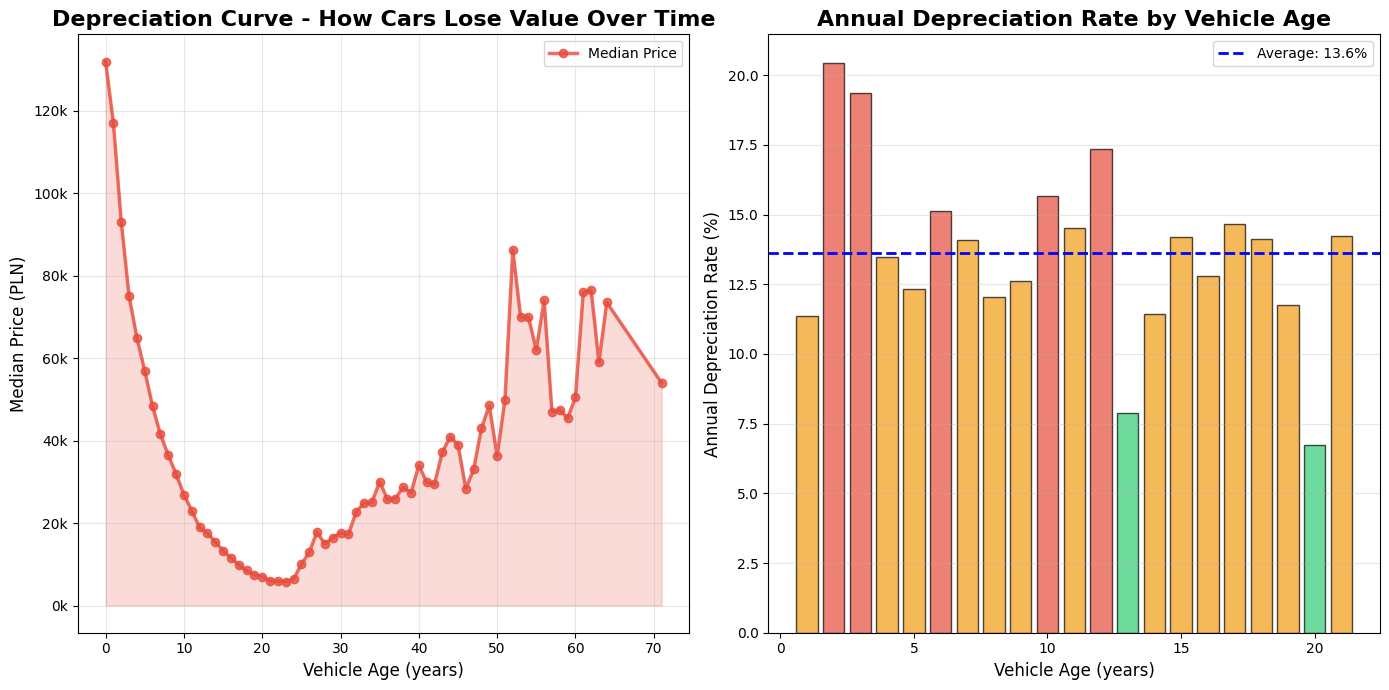

In [137]:
# Depreciation analysis
LAST_OFFER_YEAR = cars_data_cleaned['Offer_publication_date'].dt.year.min()
cars_data_cleaned['Vehicle_age'] = LAST_OFFER_YEAR - cars_data_cleaned['Production_year']

fig, axes = plt.subplots(1, 2, figsize=(14 ,7))

ax0 = axes[0]

age_price = cars_data_cleaned.groupby('Vehicle_age')['price_PLN'].agg(['median', 'mean', 'count'])
age_price = age_price[age_price['count'] >= 10] 

ax0.plot(age_price.index, age_price['median'], 'o-', linewidth=2.5, 
         markersize=6, color='#e74c3c', label='Median Price', alpha=0.8)
ax0.fill_between(age_price.index, age_price['median'], 
                  alpha=0.2, color='#e74c3c')

ax0.set_xlabel('Vehicle Age (years)', fontsize=12)
ax0.set_ylabel('Median Price (PLN)', fontsize=12)
ax0.set_title('Depreciation Curve - How Cars Lose Value Over Time', 
              fontsize=16, fontweight='bold')
ax0.legend(fontsize=10)
ax0.grid(True, alpha=0.3)
ax0.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))

valid_ages = age_price.index.values
valid_prices = age_price['median'].values

ax1 = axes[1]

depreciation_rates = []
for i in range(1, min(22, valid_ages.max())):
    if i in age_price.index and i-1 in age_price.index:
        price_now = age_price.loc[i, 'median']
        price_prev = age_price.loc[i-1, 'median']
        rate = ((price_prev - price_now) / price_prev) * 100
        depreciation_rates.append({'age': i, 'rate': rate})

if depreciation_rates:
    dep_df = pd.DataFrame(depreciation_rates)
    
    colors = ['#e74c3c' if r > 15 else '#f39c12' if r > 10 else '#2ecc71' for r in dep_df['rate']]
    
    ax1.bar(dep_df['age'], dep_df['rate'], color=colors, alpha=0.7, edgecolor='black')
    ax1.axhline(y=dep_df['rate'].mean(), color='blue', linestyle='--', 
                linewidth=2, label=f'Average: {dep_df["rate"].mean():.1f}%')
    
    ax1.set_xlabel('Vehicle Age (years)', fontsize=12)
    ax1.set_ylabel('Annual Depreciation Rate (%)', fontsize=12)
    ax1.set_title('Annual Depreciation Rate by Vehicle Age', 
                  fontsize=16, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../images/eda_depreciation_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

##### Depreciation Analysis

The first plot presents the depreciation curve, illustrating how vehicles lose value over time. It is clearly visible that cars experience the most significant value loss within the first five years after purchase, with prices declining by approximately 50% compared to their initial value.

A consistent downward trend is observed until the vehicle reaches around 25 years of age. Beyond this point, prices begin to increase slightly, although minor fluctuations remain present. This pattern suggests that vehicles older than approximately 25 years may belong to the rare, collectible, or classic segment, where scarcity and historical value can drive prices upward despite advanced age.

The second chart presents the annual depreciation rate by vehicle age. The highest depreciation rate occurs between two and three years after purchase, indicating that vehicles lose value most rapidly during the early ownership period.

Interestingly, around 13 years of age, vehicles exhibit the lowest depreciation rate. Between four and 21 years of age, depreciation remains relatively stable — with only a few exceptions — typically ranging between approximately 11% and 15% per year.

These findings confirm that vehicle age is a key structural determinant of price, though its effect is nonlinear. This suggests that modeling approaches capable of capturing nonlinear patterns — such as tree-based algorithms — may perform better than simple linear models.

#### Section II - Feature Relationships

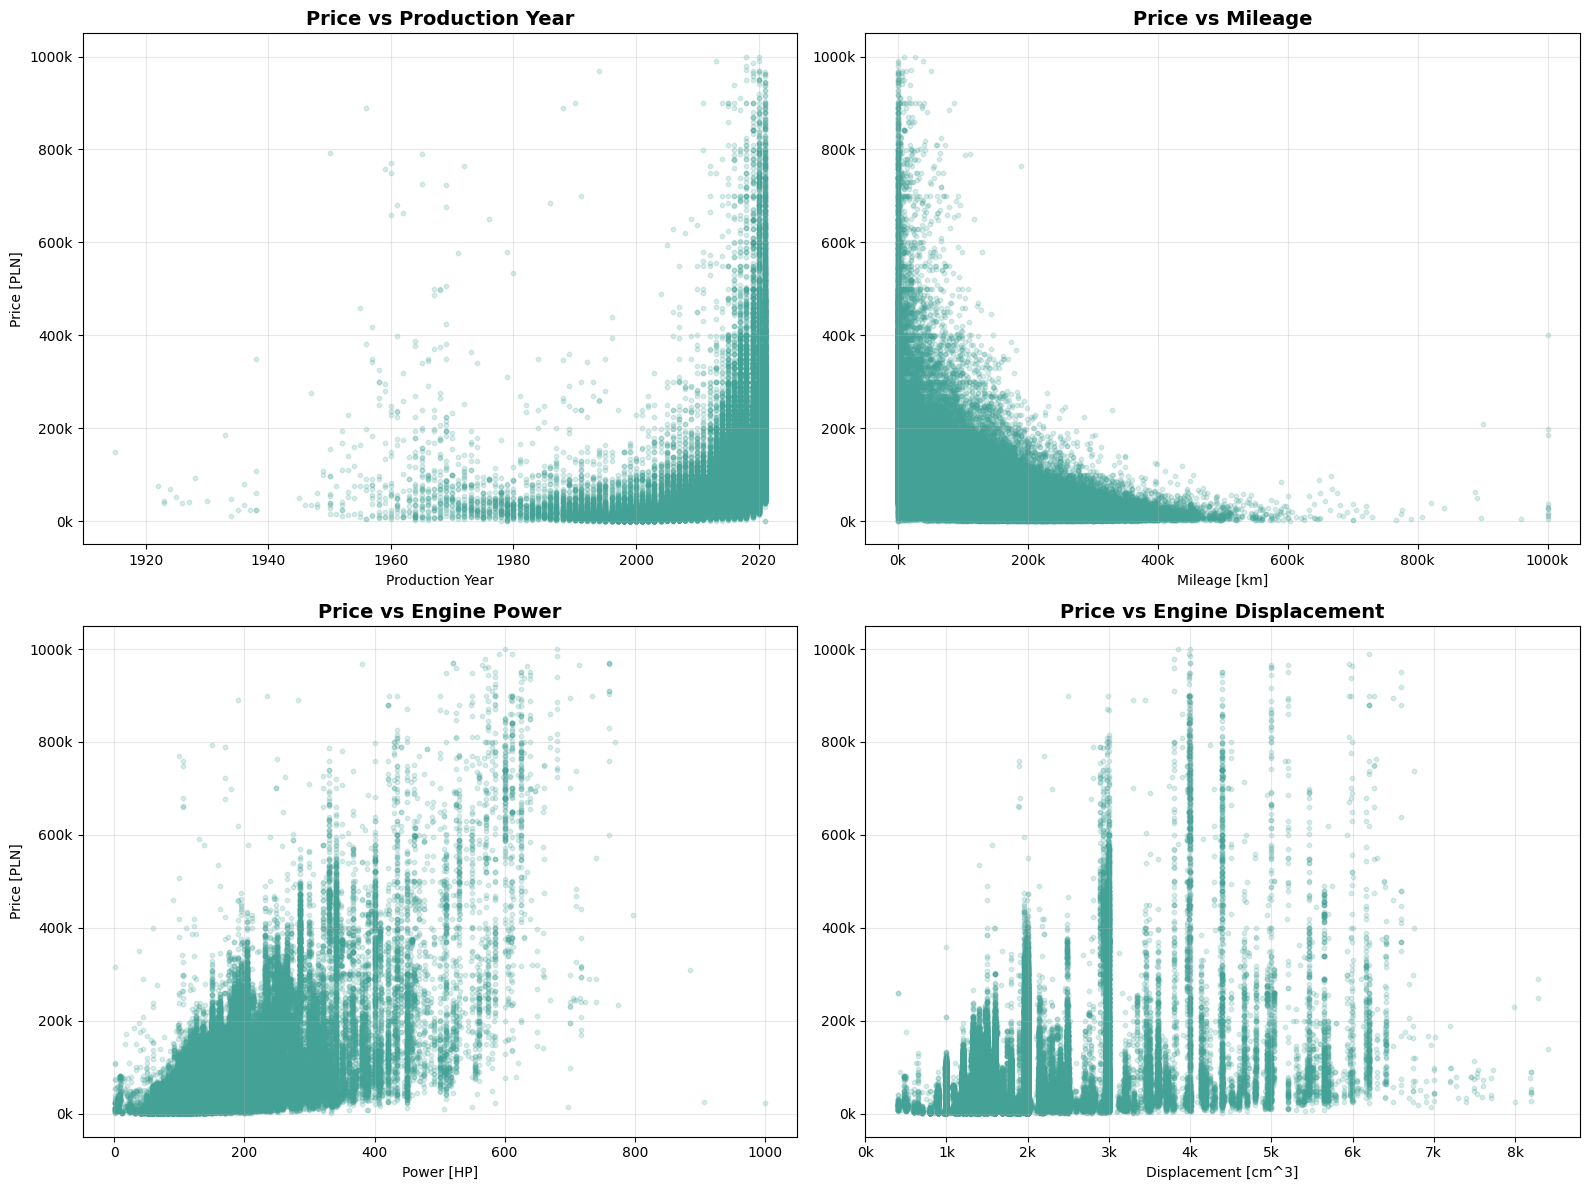

In [ ]:
# Top4 important features vs price
point_color = "#43a196"

plot_df = cars_data_cleaned[
    (cars_data_cleaned['Mileage_km'] <= 1000000) & 
    (cars_data_cleaned['price_PLN'] <= 1000000) &
    (cars_data_cleaned['Power_HP'] <= 1000)
].copy()

fig, ax = plt.subplots(2, 2, figsize=(16,12))

ax[0,0].scatter(plot_df['Production_year'], plot_df['price_PLN'], alpha=0.2, s=10, c=point_color, edgecolor=None)
ax[0,0].set_title('Price vs Production Year', weight='bold', fontsize=14)
ax[0,0].set_xlabel('Production Year')
ax[0,0].set_ylabel('Price [PLN]')

ax[0,1].scatter(plot_df['Mileage_km'], plot_df['price_PLN'], alpha=0.2, s=10, c=point_color, edgecolor=None)
ax[0,1].set_xlabel('Mileage [km]')
ax[0,1].set_title('Price vs Mileage', weight='bold', fontsize=14)

ax[1,0].scatter(plot_df['Power_HP'], plot_df['price_PLN'], alpha=0.2, s=10, c=point_color, edgecolor=None)
ax[1,0].set_title('Price vs Engine Power', weight='bold', fontsize=14)
ax[1,0].set_xlabel('Power [HP]')
ax[1,0].set_ylabel('Price [PLN]')

ax[1,1].scatter(plot_df['Displacement_cm3'], plot_df['price_PLN'], alpha=0.2, s=10, c=point_color, edgecolor=None)
ax[1,1].set_xlabel('Displacement [cm^3]')
ax[1,1].set_title('Price vs Engine Displacement', weight='bold', fontsize=14)

for a in ax.flat:
    a.grid(alpha=0.3)
    a.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))
    if a.get_xlabel() in ['Mileage [km]', 'Displacement [cm^3]']:
        a.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))

plt.tight_layout()
plt.savefig('../images/eda_scatterplots_relations_clean.png', dpi=300)
plt.show()

##### Top 4 Features vs Price

**Price vs Production Year**:

The plot shows a clear upward trend in car prices as the production year increases. Prices remain relatively stable for older vehicles, but starting around 2015, newer models exhibit significantly higher price levels. This suggests that modern vehicles — likely equipped with improved technology, enhanced safety systems, and higher market demand — command a substantial premium.

**Price vs Mileage**:

There is a strong inverse relationship between mileage and price. Vehicles with lower mileage generally have higher prices, reflecting lower wear and a longer expected remaining lifespan.

A large concentration of vehicles appears around 180,000 km, but their prices vary considerably. This dispersion is likely driven by differences in brand, engine type, condition, trim level, and overall vehicle segment.

**Price vs Power (HP)**:

The relationship indicates that vehicles with higher horsepower tend to have higher prices. High-performance cars (above 500 HP) display the widest price dispersion, likely due to variation in luxury level, brand prestige, exclusivity, and rarity.

This feature appears to be one of the strongest numeric predictors of price.

**Price vs Engine Displacement (cm³)**:

Most vehicles cluster around common engine sizes such as:

- 1,600–2,000 cm³

- 3,000 cm³

- 4,000 cm³

Prices generally increase with engine displacement; however, the relationship is less linear compared to horsepower. This is expected, as displacement does not always directly reflect actual performance due to factors such as turbocharging and hybrid systems.

Very large engines (around 7,000 cm³) are rare and typically appear in American SUVs or specialized high-performance vehicles.

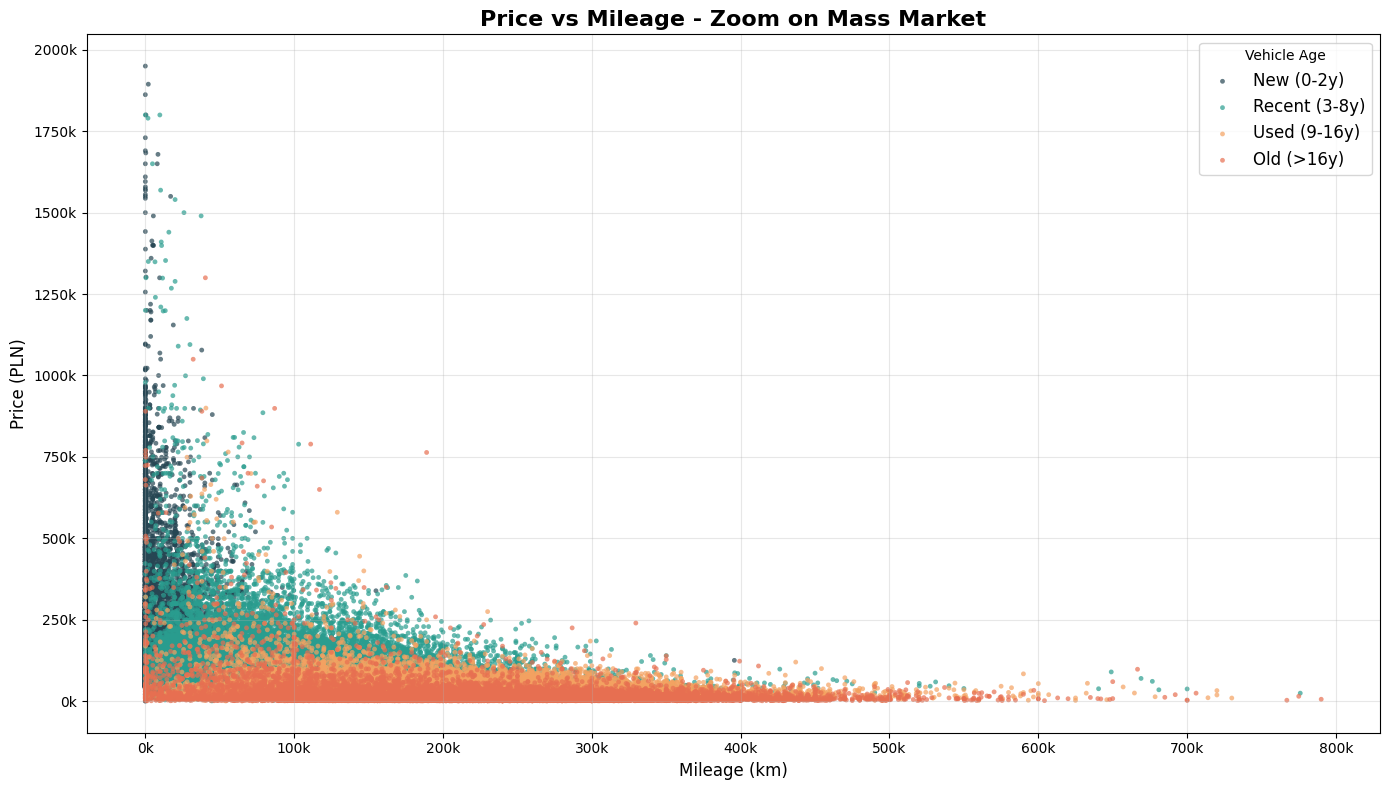

In [139]:
# Mileage vs price (colored by age)
plot_df = cars_data_cleaned[
    (cars_data_cleaned['Mileage_km'] < 800000) & 
    (cars_data_cleaned['price_PLN'] < 2000000) 
].copy()

fig, ax = plt.subplots(figsize=(14, 8))

age_groups = [
    (0, 2, 'New (0-2y)', '#264653'),      
    (3, 8, 'Recent (3-8y)', '#2a9d8f'),   
    (9, 16, 'Used (9-16y)', '#f4a261'),  
    (17, 100, 'Old (>16y)', '#e76f51')    
]

for min_age, max_age, label, color in age_groups:
    mask = (plot_df['Vehicle_age'] >= min_age) & (plot_df['Vehicle_age'] <= max_age)
    subset = plot_df[mask]
    
    ax.scatter(subset['Mileage_km'], 
               subset['price_PLN'], 
               c=color, 
               label=label,
               alpha=0.7, 
               s=12,      
               edgecolor='none')

ax.set_xlabel('Mileage (km)', fontsize=12)
ax.set_ylabel('Price (PLN)', fontsize=12)
ax.set_title('Price vs Mileage - Zoom on Mass Market', 
             fontsize=16, fontweight='bold')

ax.legend(loc='upper right', fontsize=12, title="Vehicle Age")
ax.grid(True, alpha=0.3)

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))

plt.tight_layout()
plt.savefig('../images/eda_mileage_vs_price_by_age.png', dpi=300, bbox_inches='tight')
plt.show()

##### Mileage vs Price by Vehicle Age

As shown in the chart, vehicles with the highest mileage are typically older cars (over 16 years old). Their prices are generally low, in most cases below 50,000 PLN. As the price increases, mileage tends to decrease, indicating a clear negative relationship between these two variables.

Used cars aged between 9 and 16 years rarely exceed 200,000 PLN in price. Their mileage typically ranges from 50,000 km up to 300,000 km, with higher values appearing only occasionally.

More recent vehicles (3–8 years old) mostly have mileage below 100,000 km. Beyond this threshold, the number of observations declines. Prices in this group are distributed across a broad range, mostly between 50,000 PLN and 300,000 PLN. However, there are some observations above this range, which likely represent slightly older supercars or premium-brand vehicles with high value and relatively low mileage.

New cars constitute the smallest group in the dataset. Most of them are clustered around 0 km mileage, with a wide price range—primarily between 50,000 PLN and even 1mln PLN. Some new vehicles have mileage of a few thousand kilometers (but generally not exceeding 20,000 km), and these are typically priced between 200,000 PLN and 500,000 PLN.

Overall, the chart confirms that mileage and vehicle age jointly influence price. While mileage negatively correlates with price, the effect is moderated by age and vehicle segment. Premium vehicles may retain high prices despite relatively higher mileage, whereas older mass-market cars experience both high mileage and low resale value.

This suggests strong interaction effects between Vehicle_age, Mileage_km, and Brand, which tree-based models are particularly well suited to capture.

#### Section III - Categorical Analysis

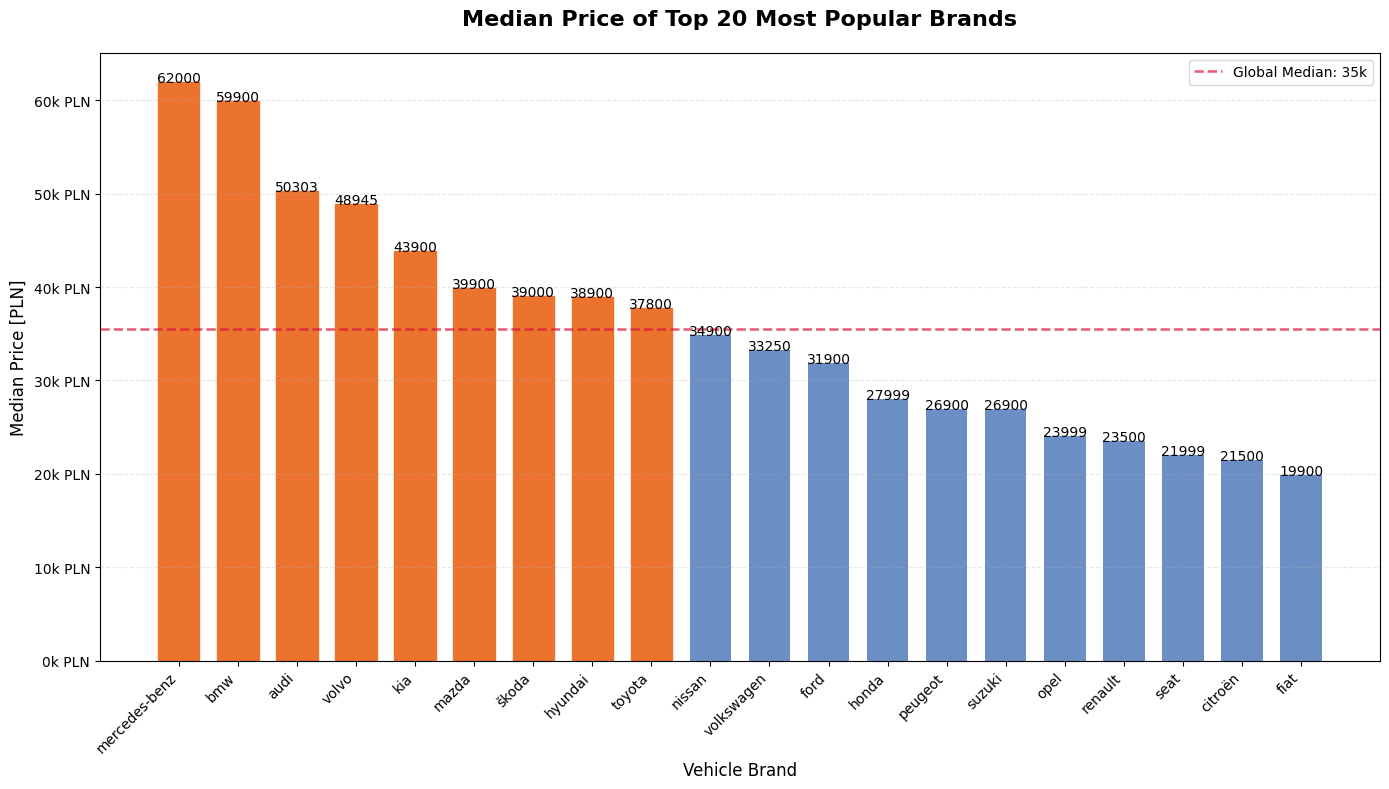

In [140]:
# Median price top 20 brands
stats = cars_data_cleaned.groupby('Vehicle_brand')['price_PLN'].agg(['median', 'count'])

top_20_popular = stats.sort_values(by='count', ascending=False).head(20)
top_20_popular = top_20_popular.sort_values(by='median', ascending=False)

fig, ax = plt.subplots(figsize=(14, 8))

bars = ax.bar(top_20_popular.index, top_20_popular['median'], color="#6B8EC5", width=0.7)

market_median_global = cars_data_cleaned['price_PLN'].median()
ax.axhline(market_median_global, color='crimson', linestyle='--', linewidth=1.8, alpha=0.7, label=f'Global Median: {int(market_median_global/1000)}k')

for i in range(len(bars)):
    if bars[i].get_height() > market_median_global:
        bars[i].set_color("#EB732D")

ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{int(x/1000)}k PLN'))

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height()+5,
             int(bar.get_height()), ha='center', fontsize=10)

plt.title('Median Price of Top 20 Most Popular Brands', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Vehicle Brand', fontsize=12)
plt.ylabel('Median Price [PLN]', fontsize=12)
plt.xticks(rotation=45, ha='right') 

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('../images/eda_median_preice_top20_brands,png', dpi=300, bbox_inches='tight')
plt.show()

##### Top Brands Price Comparison

The bar chart presents the most popular vehicle brands along with their median prices. Brands with prices above the global median are highlighted, as they represent the higher-value market segment.

Mercedes-Benz ranks first, with a median price of approximately 62,000 PLN. The second and third positions are also occupied by German brands — BMW and Audi — with median prices of around 60,000 PLN and 50,000 PLN, respectively. Another premium European brand, Volvo, also reaches a relatively high median price of nearly 49,000 PLN.

The remaining brands show noticeably lower median prices, ranging from approximately 20,000 PLN to 40,000 PLN. These are primarily vehicles from Asian, French, and American manufacturers. Their median prices are roughly 2–3 times lower than those of the leading German brands.

Overall, German brands clearly dominate the upper segment of the market, both in terms of popularity and pricing within the analyzed dataset.

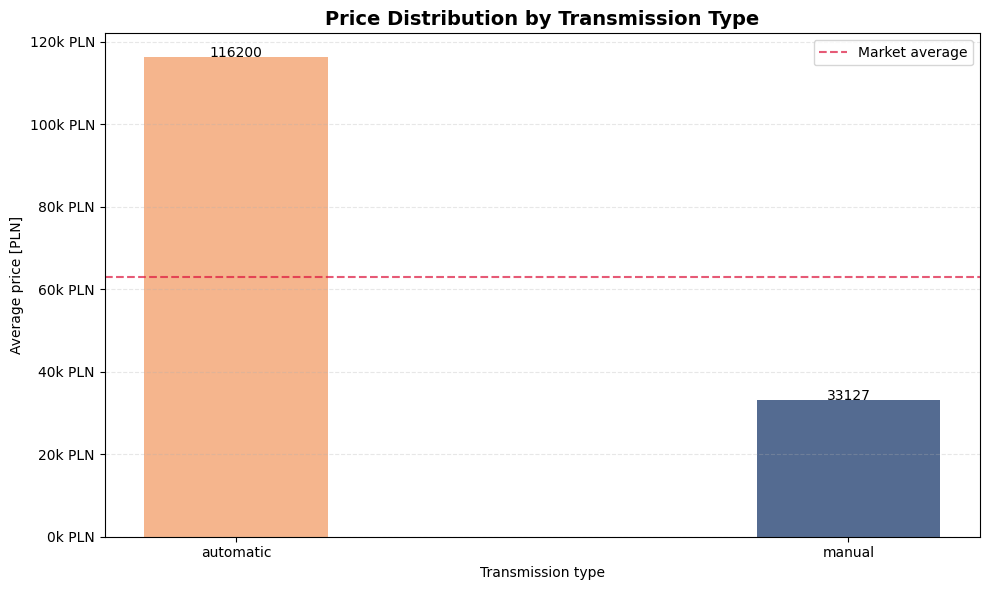

In [141]:
# Price distribution by transmission type
stats = (
    cars_data_cleaned.groupby('Transmission')
    .agg(avg_price=('price_PLN','mean'), count=('price_PLN','size'))
    .sort_values('avg_price', ascending=False)
)

fig, ax = plt.subplots(figsize=(10,6))

bars = ax.bar(stats.index, stats['avg_price'], color=["#F5B58D", "#546B91"], width = 0.3)

market_mean = cars_data_cleaned['price_PLN'].mean()
ax.axhline(market_mean, color='crimson', linestyle='--', alpha=0.7, label='Market average')

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height()+5,
             int(bar.get_height()), ha='center', fontsize=10)

ax.set_title('Price Distribution by Transmission Type', fontsize=14, weight='bold')
ax.set_ylabel('Average price [PLN]')
ax.set_xlabel('Transmission type')

ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{int(x/1000)}k PLN'))

ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig('../images/eda_price_distribution_by_transmission_type.png', dpi=300, bbox_inches='tight')
plt.show()

##### Price Comparison by Transmission Type

The bar plot presents the average car price depending on the type of transmission: manual or automatic. Vehicles equipped with automatic transmission show a clear price advantage, with an average price of nearly 120,000 PLN. In contrast, manual cars have an average price of less than 40,000 PLN — roughly three times lower than automatic vehicles.

This substantial difference likely reflects market structure. Automatic transmissions are more commonly found in newer or premium vehicles, which typically command higher prices. Manual cars, on the other hand, are often older, smaller, or entry-level models, which tend to be less expensive.

From a modeling perspective, this suggests that Transmission Type is an important categorical feature. A machine learning model may learn that:

- Automatic transmission is associated with higher vehicle prices,

- Manual transmission is more common in lower price segments.

Moreover, transmission type may interact with other features (e.g., brand, engine size, vehicle segment), which could further influence price predictions.

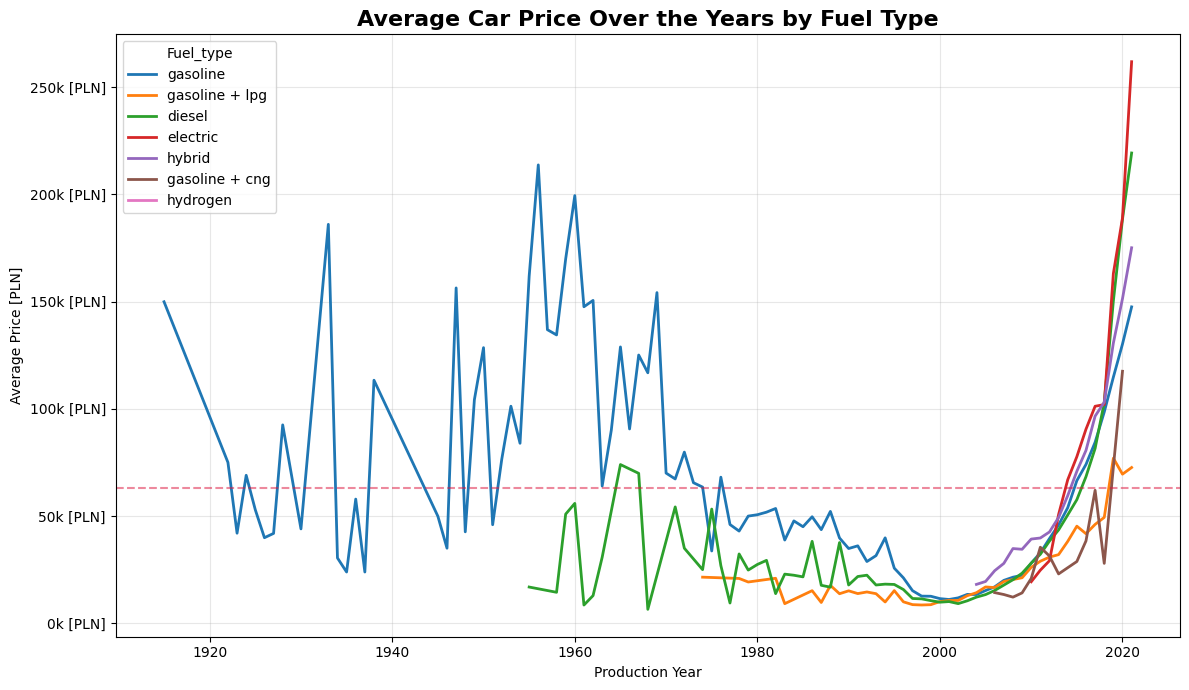

In [142]:
# Car price over the years by fuel type
plot_df = cars_data_cleaned[
    (cars_data_cleaned['Mileage_km'] <= 1000000) & 
    (cars_data_cleaned['price_PLN'] <= 1000000) &
    (cars_data_cleaned['Power_HP'] <= 1000)
].copy()

fig, ax = plt.subplots(figsize=(12, 7))
sns.lineplot(data=plot_df,
            x='Production_year',
            y='price_PLN',
            hue='Fuel_type',
            errorbar=None, 
            lw=2)

overall_mean = cars_data_cleaned['price_PLN'].mean()
ax.axhline(overall_mean, color='crimson', linestyle='--', alpha=0.5, label='Market average')

ax.set_title("Average Car Price Over the Years by Fuel Type", weight='bold', fontsize=16)
ax.set_xlabel("Production Year")
ax.set_ylabel("Average Price [PLN]")

ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{int(x/1000)}k [PLN]'))

ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../images/eda_average_car_price_over_the_years_by_fuel_type', dpi=300, bbox_inches='tight')
plt.show()

##### Car Price Analysis by Fuel Type

From the 1920s until the late 1990s, gasoline-powered cars dominated vehicle production, and their prices fluctuated gradually over the decades. Starting in the 1980s and 1990s, diesel vehicles became increasingly popular, particularly in Europe, and were often priced slightly lower than comparable gasoline models due to market positioning and fuel efficiency advantages.

From the late 1990s onward, price differences across fuel types became more structured, but a noticeable shift occurred after 2010. During this period, the average price of vehicles across all fuel types began to rise. The most significant increase is observed among electric vehicles, which show a sharp upward trend driven by technological advancements, battery costs, and their positioning in the premium segment.

Diesel, hybrid, and gasoline vehicles have also experienced price growth, although at a more moderate pace compared to electric models. The most moderate increases are observed for gasoline + CNG and gasoline + LPG vehicles, which typically remain positioned in more cost-sensitive market segments.

Additionally, fuel type may interact strongly with other variables such as production year, engine power, and brand. For example, electric vehicles are typically newer and often belong to higher-end brands, meaning that the model may capture nonlinear relationships and feature interactions when using tree-based algorithms.

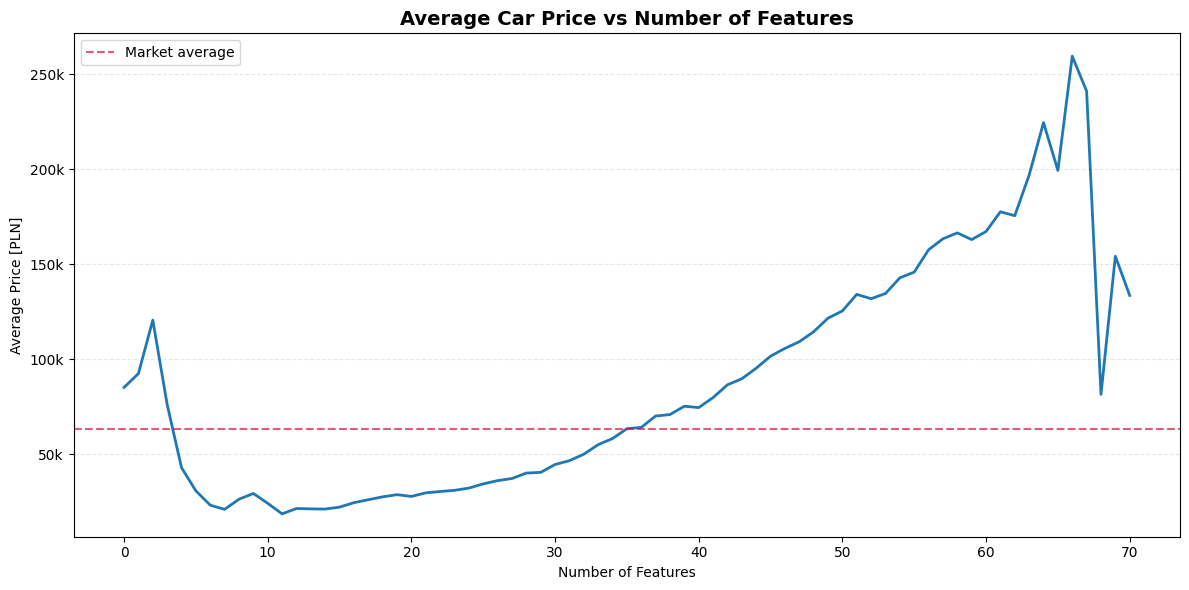

In [143]:
# Average Car Price vs Number of Features
def count_features(f):
    f = str(f).strip('[]').strip()
    if not f or f == '':
        return 0
    return len([ft.strip() for ft in f.split(',') if f.strip()])

cars_data_cleaned['Num_features'] = cars_data_cleaned['Features'].apply(count_features)

stats = cars_data_cleaned.groupby('Num_features').agg(
    avg_price = ('price_PLN', 'mean'),
    count = ('price_PLN', 'size')
).reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(data=stats, x = 'Num_features', y = 'avg_price', linewidth = 2)

market_mean = cars_data_cleaned['price_PLN'].mean()
plt.axhline(market_mean, color='crimson', linestyle='--', alpha=0.7, label='Market average')

plt.title('Average Car Price vs Number of Features', fontsize=14, weight='bold')
plt.xlabel('Number of Features')
plt.ylabel('Average Price [PLN]')

plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('../images/eda_average_car_price_vs_number_of_features.png', dpi=300, bbox_inches='tight')
plt.show()

##### Price vs Number of Vehicle Features

The line plot illustrates a strong positive relationship between the number of vehicle features and the average car price. Vehicles with minimal equipment (approximately 5–30 features) exhibit relatively low and stable average prices, typically ranging between 20,000 and 40,000 PLN. There is an interesting spike in the 0–2 features range, which likely represents a specific vehicle segment or a small group of atypical listings.

From around 15 features onward, a clear upward trend becomes visible. Average prices increase steadily from approximately 20,000 PLN to over 150,000 PLN as the equipment level rises. The most well-equipped vehicles (60–68 features) command premium prices exceeding 200,000 PLN, with peaks reaching approximately 260,000 PLN. These vehicles most likely belong to the luxury or high-end segment.

The sharp decline observed beyond 68 features is likely driven by a very limited sample size in this extreme range. Nevertheless, the overall trend clearly demonstrates that equipment level is a strong determinant of vehicle price.

This relationship suggests that the number of features is a highly informative variable for price prediction. It may capture not only equipment richness but also underlying vehicle class and brand positioning.

#### Section IV - Multivariate and Correlation

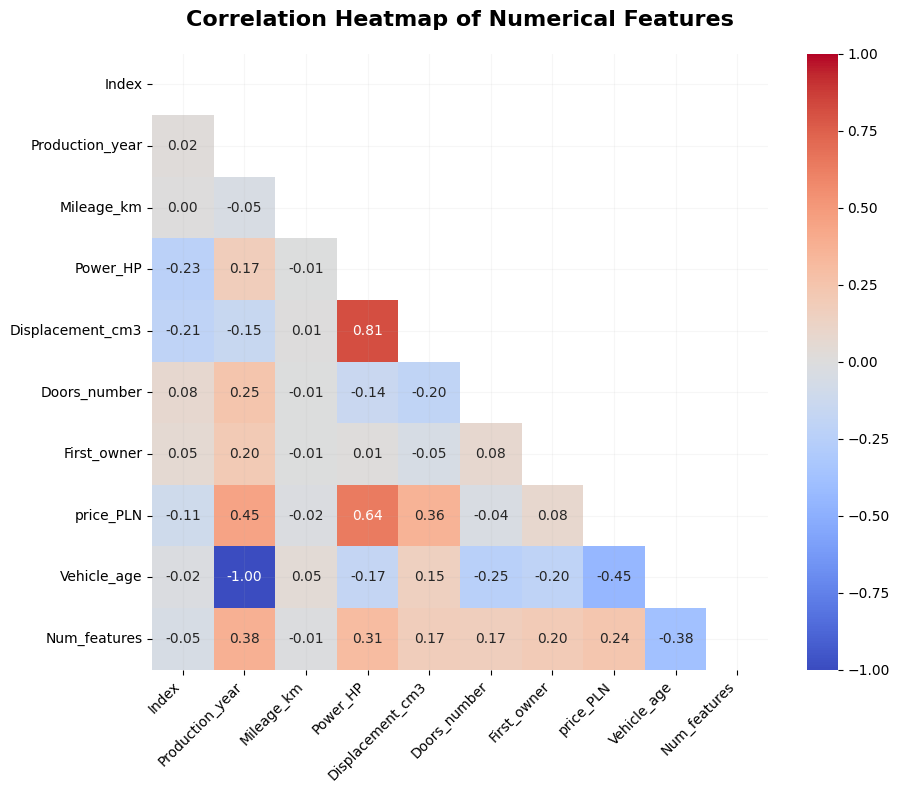

In [144]:
# Correlation heatmap
corr = cars_data_cleaned.select_dtypes(include=[np.number]).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(corr,
            mask=mask,
            annot=True,
            vmin=-1,
            vmax=1, 
            cmap='coolwarm', 
            center=0, 
            fmt='.2f',
            square=True
)
plt.title("Correlation Heatmap of Numerical Features", 
          fontsize=16, 
          fontweight="bold", 
          pad=20)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.grid(True, alpha=0.1)
plt.savefig('../images/eda_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

##### Correlation Heatmap Analysis

The heatmap shows that the strongest correlation exists between Power_HP and Displacement_cm3, with a coefficient of 0.81. This is expected, as larger engine displacement generally corresponds to higher engine power.

A strong positive correlation is also observed between price_PLN and Power_HP, confirming that vehicles with higher horsepower tend to be more expensive. Similarly, price shows a positive relationship with Production_year, indicating that newer cars generally command higher prices. The correlation between price and engine displacement is also positive, though slightly weaker.

A very strong negative correlation appears between Production_year and Vehicle_age, since vehicle age is directly derived from production year. These two variables essentially represent the same information in inverse form, meaning one of them should likely be removed during feature selection to avoid multicollinearity.

Price shows a moderate negative correlation with Vehicle_age (around -0.45), suggesting that older cars tend to be cheaper, although the relationship is not perfectly linear due to premium or collectible vehicles. The correlation between price and Doors_number is relatively weak (around -0.25), indicating that the number of doors has limited direct influence on price.

A moderate relationship is also observed between Number_of_features and Vehicle_age (around -0.38), which suggests that newer vehicles tend to be better equipped.

It is important to clarify that a correlation of 0.45 is not low — it represents a moderate relationship. Additionally, low linear correlation does not necessarily mean a feature is useless. Tree-based models (such as Random Forest, LightGBM, or CatBoost) can capture nonlinear relationships and feature interactions that are not visible in simple correlation analysis.

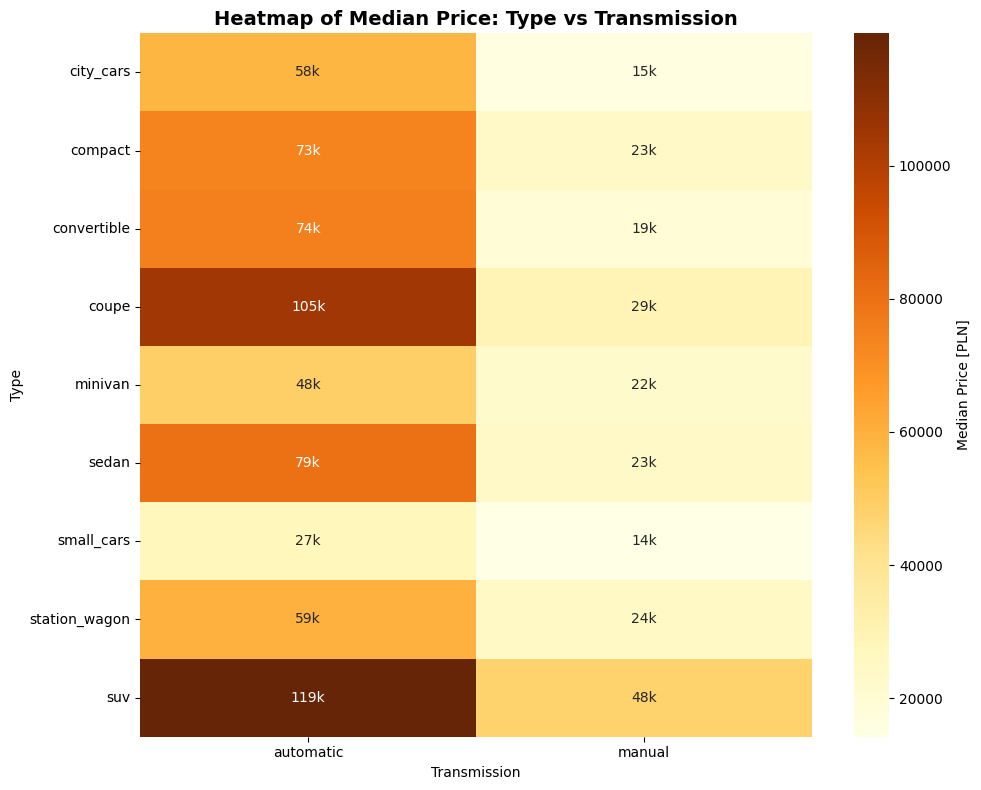

In [145]:
# Type vs transmission
pivot_table = cars_data_cleaned.pivot_table(
    values='price_PLN', 
    index='Type', 
    columns='Transmission', 
    aggfunc='median'
).dropna() 

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_table, 
            annot=True, 
            fmt=".0f", 
            cmap="YlOrBr", 
            cbar_kws={'label': 'Median Price [PLN]'})

for text in plt.gca().texts:
    val = float(text.get_text())
    text.set_text(f'{int(val/1000)}k')

plt.title('Heatmap of Median Price: Type vs Transmission', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../images/eda_heatmap_of_median_price_type_vs_transmission.png', dpi=300, bbox_inches='tight')
plt.show()

##### Vehicle Type vs Transmission – Price Analysis

From the type vs transmission heatmap, we can clearly observe that automatic vehicles are consistently more expensive than manual ones across nearly all body types.

SUVs remain the most expensive segment in both transmission groups. In the automatic market, SUVs reach a median price of approximately 119,000 PLN, while in the manual segment, SUVs reach around 48,000 PLN. This substantial gap highlights the strong association between automatic transmission and higher vehicle value.

Among automatic vehicles, other high-median segments include:

- Coupés (~105,000 PLN), often representing sports or premium vehicles,

- Sedans (~79,000 PLN), which typically include both executive and mid-range models.

The lowest median prices within the automatic segment are observed for small cars, which are generally associated with budget-friendly and less premium brands.

In contrast, the manual segment shows a very different structure. Most body types cluster around a median price of approximately 29,000 PLN (with SUVs being the exception). This suggests that manual vehicles are more common in older, mass-market, and entry-level segments.

These findings indicate that transmission type and vehicle body type interact strongly in determining price. Automatic transmission appears to be associated with newer, more premium segments, while manual transmission is concentrated in older and more affordable vehicles.

The exploratory analysis provided a comprehensive overview of the factors driving used car prices in the Polish market. The key findings are summarized below:

- Primary Price Drivers: Strong correlations were identified between Price and technical specifications. Vehicle Age (Production Year) and Mileage are the most significant drivers of depreciation, showing a clear negative correlation with price. Conversely, Engine Power (HP) is the strongest positive predictor of value.

- Brand Segmentation: The categorical analysis revealed distinct price tiers. While mass-market brands dominate in volume, premium brands (e.g., BMW, Mercedes-Benz, Audi) maintain significantly higher median prices, often exceeding the global market median even in older year brackets.

- Technical Trends: Multivariate analysis confirmed that Automatic Transmissions consistently command a price premium across all body types. SUVs and Estates (Combi) represent the highest-value segments, showing better value retention compared to smaller body styles like hatchbacks.

- Fuel & Technology: Price trends over time highlight the rising valuation of Hybrid and Electric vehicles in recent years, though traditional Internal Combustion Engines (Diesel/Petrol) still constitute the bulk of the stable secondary market.

- Data Quality & Readiness: By addressing outliers (clipping mileage and price extremes) and handling missing values, the dataset has been refined. The identified linear and non-linear relationships confirm that the data is well-suited for advanced predictive modeling (e.g., Gradient Boosting or Random Forest).

---

## Feature Engineering

Creating new features is crucial for helping models capture nonlinear relationships and improve price prediction performance.

The Age_category feature groups vehicles based on their age, which is particularly important for modeling depreciation effects. This categorization can help capture structural differences between new, recent, used, and older vehicles. Additionally, binary indicators derived from such categories may improve the performance of tree-based models by enabling clearer decision splits.

In [147]:
def new_categories(age):
    if age < 3:
        return 'New'
    elif age < 9:
        return 'Recent'
    elif age < 17:
        return 'Used'
    else:
        return 'Old'
    
cars_data_cleaned['Age_category'] = cars_data_cleaned['Vehicle_age'].apply(new_categories)

cars_data_cleaned['Is_new_car'] = (cars_data_cleaned['Vehicle_age'] < 3).astype(int)
cars_data_cleaned['Is_old_car'] = (cars_data_cleaned['Vehicle_age'] > 16).astype(int)

By normalizing mileage by vehicle age, we reduce bias caused by simple time accumulation and allow the model to better distinguish between lightly used and heavily used vehicles. This engineered feature may improve predictive performance by capturing usage efficiency rather than absolute mileage.

In [148]:
cars_data_cleaned['Mileage_per_year'] = cars_data_cleaned['Mileage_km'] / cars_data_cleaned['Vehicle_age'].replace(0, 1)

def usage_category(mileage_per_year):
    if mileage_per_year < 10000:
        return 'Low'
    elif mileage_per_year < 20000:
        return 'Average'   
    elif mileage_per_year < 30000:
        return 'High'      
    else:
        return 'Very_High'  
    
cars_data_cleaned['Usage_intensity'] = cars_data_cleaned['Mileage_per_year'].apply(usage_category)

The Power_per_liter feature acts as a normalized performance metric, capturing engine efficiency rather than raw output. This transformation reduces redundancy between displacement and horsepower while providing a more meaningful signal of technological sophistication, which may significantly enhance model performance.

In [149]:
cars_data_cleaned['HP_per_liter'] = cars_data_cleaned['Power_HP'] / (cars_data_cleaned['Displacement_cm3'] / 1000)

def performance_category(hp_per_liter):
    if pd.isna(hp_per_liter):
        return 'Unknown'
    elif hp_per_liter < 60:
        return 'Economy'
    elif hp_per_liter < 100:
        return 'Standard'     
    elif hp_per_liter < 150:
        return 'Performance'
    else:
        return 'High_Performance' 
    
cars_data_cleaned['Performance_category'] = cars_data_cleaned['HP_per_liter'].apply(performance_category)

Some premium segment cars need to be treated separately because their values can fluctuate by several hundred thousand PLN. Therefore, it is useful to divide the car market into two segments: premium and mass-market vehicles. This distinction helps models better capture differences in pricing patterns, as premium cars often follow different value dynamics than standard vehicles.

Moreover, an additional variable is created to identify supercars, whose prices can be highly specific and sometimes reach several million PLN. Including this feature allows the model to account for extreme price ranges that are not typical for most vehicles.


In [150]:
premium_brands = [
    'alfa romeo', 'alpine', 'aston martin', 'audi', 'bentley', 'bmw',
    'cadillac', 'cupra', 'ds automobiles', 'ferrari', 'infiniti',
    'jaguar', 'lamborghini', 'land rover', 'lexus', 'lincoln',
    'lotus', 'maserati', 'maybach', 'mclaren', 'mercedes-benz',
    'mini', 'porsche', 'rolls-royce', 'tesla'
]

cars_data_cleaned['Is_premium'] = cars_data_cleaned['Vehicle_brand'].isin(premium_brands).astype('Int64')

cars_data_cleaned['Is_supercar'] = ((cars_data_cleaned['Power_HP'] > 500) & (cars_data_cleaned['Is_premium'] == 1)).astype('Int64')

As the depreciation charts showed, cars older than 25 years often begin to increase in value. From that point, some vehicles may become rare or collectible. Therefore, it is useful for the model to consider whether a car belongs to this category.

To capture this effect, we create an is_collector variable, which indicates whether a vehicle may have collector potential. This feature helps the model recognize specific cars whose prices may deviate from standard depreciation patterns.


In [151]:
cars_data_cleaned['is_collector'] = (cars_data_cleaned['Vehicle_age'] > 25).astype(int)

Some columns are not informative for further analysis or model development and can therefore be removed:

- Vehicle_generation: This feature contains a substantial number of missing values, which reduces its reliability. Additionally, we already have sufficient information from features such as brand, model, and other technical specifications to capture vehicle characteristics.

- Production_year: This variable is highly correlated with Vehicle_age, as demonstrated in the correlation heatmap. Since Vehicle_age directly reflects the depreciation effect and contains the same underlying information, Production_year can be removed to avoid redundancy and multicollinearity.

- Index and Offer_publication_date: These columns do not provide meaningful predictive information for price estimation.

In [152]:
cols_to_drop_fe = ['Vehicle_generation', 'Production_year', 'Index', 'Offer_publication_date']

cars_data_cleaned = cars_data_cleaned.drop(columns=cols_to_drop_fe, errors='ignore')

The next step is to perform a train–test split and handle the remaining missing values. The imputation process will be applied separately to numerical and categorical features.

In [153]:
# Train test split
X = cars_data_cleaned.drop('price_PLN', axis=1)
y = cars_data_cleaned['price_PLN']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2 ,random_state=42)

After performing the train–test split, the next step is to handle missing values and create additional transformed features. For the Doors_number variable, missing values are filled using the mode, as the number of doors represents a small discrete natural number, making the most frequent value a more appropriate choice than the mean or median. For the remaining numerical variables, the median is used to impute missing values, as it is more robust to outliers than the mean.

Once the missing values are properly handled, logarithmic transformations of selected variables can be created. It is important to perform the imputation step before generating derived features, because creating logarithmic variables prior to filling missing values could introduce additional undefined values and propagate missing data through the dataset.

After completing the imputation process, we can safely generate derived features, including logarithmic transformations and other engineered variables, which may help the model capture non-linear relationships between predictors and the target variable.

In [154]:
# Filling missing values (numeric columns)
X_train_filled = X_train.copy()
X_test_filled = X_test.copy()

numeric_cols_with_missing = ['Mileage_km', 'Power_HP', 'Displacement_cm3', 'Doors_number']

for col in numeric_cols_with_missing:
    if col == 'Doors_number':
        fill_value = X_train_filled[col].mode()[0]
    else:
        fill_value = X_train_filled[col].median()

    X_train_filled[col] = X_train_filled[col].fillna(fill_value)
    X_test_filled[col] = X_test_filled[col].fillna(fill_value)

# Since the base columns have been filled, we can now proceed to filling the derived columns
def filling_derived_columns(df):
    df['Mileage_km_log'] = np.log1p(df['Mileage_km'])
    df['Power_HP_log'] = np.log1p(df['Power_HP'])
    df['Displacement_cm3_log'] = np.log1p(df['Displacement_cm3'])
    
    df['HP_per_liter'] = df['Power_HP'] / (df['Displacement_cm3'] / 1000)
    df['HP_per_liter'] = df['HP_per_liter'].replace([np.inf, -np.inf], 0)
    df['Mileage_per_year'] = df['Mileage_km'] / df['Vehicle_age'].replace(0, 1)
    
    return df

X_train_filled = filling_derived_columns(X_train_filled)
X_test_filled = filling_derived_columns(X_test_filled)

In [155]:
# Filling missing values (categorical columns)
if 'Drive' in X_train_filled.columns:
    train_mode = X_train_filled['Drive'].mode()[0] if not X_train_filled['Drive'].mode().empty else 'Unknown'
    
    X_train_filled['Drive'] = X_train_filled['Drive'].fillna(train_mode)
    X_test_filled['Drive'] = X_test_filled['Drive'].fillna(train_mode)
    
if 'Transmission' in X_train_filled.columns:
    train_mode = X_train_filled['Transmission'].mode()[0]
    
    X_train_filled['Transmission'] = X_train_filled['Transmission'].fillna(train_mode)
    X_test_filled['Transmission'] = X_test_filled['Transmission'].fillna(train_mode)

X_train = X_train_filled
X_test = X_test_filled

Most relationships between vehicle characteristics and car prices are non-linear. For instance, two cars produced in the same year may differ significantly in price due to differences in mileage, engine power, or available amenities. Because of these complexities, simple linear relationships may not be sufficient to accurately model price behavior.

To better capture these non-linear effects, squared transformations of several key variables were introduced, including Mileage, Power, and Vehicle_age. These transformations allow the model to account for curvature in the relationship between predictors and the target variable, which is common in car price depreciation patterns.

In addition to non-linear transformations, feature interactions were also created. In many cases, the combined effect of two variables can be more informative than each variable considered separately. For example, the interaction between vehicle age and mileage can better represent the overall usage intensity of a vehicle.

Furthermore, several derived features were introduced to encode more complex relationships within the data. Variables such as Mileage_per_year and HP_per_liter aim to capture vehicle usage and engine efficiency more precisely. These engineered features help the model extract meaningful patterns that might otherwise be difficult to learn directly from the raw variables.

In [156]:
X_train['Vehicle_age_squared'] = X_train['Vehicle_age'] ** 2
X_test['Vehicle_age_squared'] = X_test['Vehicle_age'] ** 2

X_train['Power_HP_squared'] = X_train['Power_HP'] ** 2
X_test['Power_HP_squared'] = X_test['Power_HP'] ** 2

X_train['Mileage_km_squared'] = X_train['Mileage_km'] ** 2
X_test['Mileage_km_squared'] = X_test['Mileage_km'] ** 2

X_train['Age_Mileage_interaction'] = X_train['Vehicle_age'] * X_train['Mileage_km']
X_test['Age_Mileage_interaction'] = X_test['Vehicle_age'] * X_test['Mileage_km']

X_train['Power_Age_interaction'] = X_train['Power_HP'] * X_train['Vehicle_age']
X_test['Power_Age_interaction'] = X_test['Power_HP'] * X_test['Vehicle_age']

if 'Mileage_per_year' in X_train.columns:
    X_train['Mileage_per_year_Age'] = X_train['Mileage_per_year'] * X_train['Vehicle_age']
    X_test['Mileage_per_year_Age'] = X_test['Mileage_per_year'] * X_test['Vehicle_age']

Important matter during creating and preparing new data is encoding categorical columns, as machine learning models cannot interpret text or sentences directly. Models operate only on numerical values, therefore categorical variables must be transformed into a numerical representation.

In this project, separate pipelines were created for each model. The pipeline for linear regression includes polynomial features in order to capture potential non-linear relationships between variables. Additionally, SimpleImputer is used to handle missing values that the model cannot process directly, while PowerTransformer helps transform feature distributions to be closer to a Gaussian distribution. Finally, categorical variables are encoded so they can be used by the model.

Tree-based models require a slightly different preprocessing approach. These models are generally better at capturing non-linear relationships and can sometimes handle missing values more effectively. However, to ensure consistency and stability of the training process, SimpleImputer is still applied to fill missing values. Categorical variables are encoded using OrdinalEncoder, which converts category labels into numerical values.

In [157]:
# Categorical columns encoding
num_pipeline_tree = SimpleImputer(strategy='median')

cat_pipeline_tree = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor_tree = ColumnTransformer([
    ('num', num_pipeline_tree, make_column_selector(dtype_include='number')),
    ('cat', cat_pipeline_tree, make_column_selector(dtype_include=['object', 'category']))
])

In [158]:
num_cols = ['Mileage_km', 'Power_HP', 'Displacement_cm3', 'Vehicle_age']
cat_cols_to_encode = ['Vehicle_brand', 'Vehicle_model']
cat_cols_simple = ['Fuel_type', 'Transmission', 'Drive', 'Type']

num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('yeo', PowerTransformer(method='yeo-johnson')),
    ('poly', PolynomialFeatures(degree=2, interaction_only=True))

])

target_encoder = TargetEncoder(smoothing=200)

preprocessor_mastered = ColumnTransformer([
    ('num', num_transformer, num_cols),
    ('target', target_encoder, cat_cols_to_encode),
    ('cat_simple', OneHotEncoder(handle_unknown='ignore'), cat_cols_simple)
])

## Models Building

### First Model - Linear Regression

Linear Regression is important in car price prediction because it provides a strong and interpretable baseline for understanding how key factors such as mileage, year of production, and engine size affect vehicle prices. Its coefficients make it easy to quantify the impact of each feature, which helps validate domain assumptions and guide feature engineering.

In [159]:
#Pipeline
pipeline_reg = Pipeline([
    ('preprocessor', preprocessor_mastered),
    ('model', Ridge())
])

In [160]:
# Setting hyperparameters
param_grid = {
    'model__alpha': [0.1, 1.0, 5.0, 10.0, 100.0],
    'model__solver': ['auto', 'cholesky', 'lsqr'],
    'model__fit_intercept': [False, True]
}

scoring = {
    'r2': 'r2',
    'neg_rmse': 'neg_root_mean_squared_error',
    'neg_mae': 'neg_mean_absolute_error',
    'neg_mse': 'neg_mean_squared_error'
}

In [161]:
# Using KFold and GridSearch
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

grid_log = GridSearchCV(
    estimator=pipeline_reg,
    param_grid=param_grid,
    scoring=scoring,
    refit='neg_rmse',
    cv=kfold,
    n_jobs=-1,
    verbose=1
)

In [162]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

In [164]:
grid_log.fit(X_train, y_train_log)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,estimator,"Pipeline(step...l', Ridge())])"
,param_grid,"{'model__alpha': [0.1, 1.0, ...], 'model__fit_intercept': [False, True], 'model__solver': ['auto', 'cholesky', ...]}"
,scoring,"{'neg_mae': 'neg_mean_absolute_error', 'neg_mse': 'neg_mean_squared_error', 'neg_rmse': 'neg_root_mean_squared_error', 'r2': 'r2'}"
,n_jobs,-1
,refit,'neg_rmse'
,cv,KFold(n_split... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('target', ...), ...]"


In [ ]:
#Best Lineear Regression Model
best_lin = grid_log.best_estimator_

In [ ]:
y_test_log_pred = best_lin.predict(X_test)
y_train_log_pred = best_lin.predict(X_train)

y_train_log_pred = np.clip(y_train_log_pred, y_train_log.min(), y_train_log.max())
y_test_log_pred = np.clip(y_test_log_pred, y_train_log.min(), y_train_log.max())

y_train_pred = np.expm1(y_train_log_pred)
y_test_pred = np.expm1(y_test_log_pred)

In [ ]:
# Checking some metrics
def metrics(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)

    return {'R2': r2, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape}

train_metrics = metrics(y_train, y_train_pred)
test_metrics = metrics(y_test, y_test_pred)
metrics_df = pd.DataFrame({ 
    'Train': train_metrics,
    'Test': test_metrics
})

formatted_df = metrics_df.style.format({
    'Train Set': "{:,.4f}" if "R2" in metrics_df.index else "{:,.2f}",
    'Test Set': "{:,.4f}" if "R2" in metrics_df.index else "{:,.2f}"
})
metrics_df

,Train,Test
R2,0.782703,0.830532
RMSE,41695.739493,34358.349917
MAE,15054.854512,14797.910991
MAPE,0.289449,0.293214


### Linear Regression Performance

The Linear Regression model performs reasonably well as a baseline approach for predicting car prices. It explains a substantial portion of the variability in the data, achieving an ($R^2$) of 0.831 on the test set, which indicates that approximately 83.1% of the variation in car prices is captured by the model.

The training and testing results are relatively consistent, with ($R^2$) values of 0.783 and 0.831 respectively. This suggests that the model does not suffer from significant overfitting and generalizes reasonably well to unseen data.

Prediction errors remain moderate. The Mean Absolute Error (MAE) on the test set equals 14,798 PLN, meaning that the model’s predictions deviate from the actual prices by roughly this amount on average. Similarly, the Mean Absolute Percentage Error (MAPE) is approximately 29.3%, indicating that predictions differ from true prices by about 29% on average.

However, the Root Mean Squared Error (RMSE) reaches 34,358 PLN, which is noticeably higher than the MAE. This gap suggests that the model is influenced by several large prediction errors, most likely caused by extreme values or outliers in the dataset, such as luxury vehicles, supercars, or rare collector models. These observations are more difficult to model accurately using a simple linear relationship.

Overall, the results indicate that Linear Regression provides a solid baseline model and captures general pricing patterns in the used car market. Nevertheless, its sensitivity to outliers and limited ability to capture complex, non-linear relationships suggests that more advanced models may further improve predictive performance.

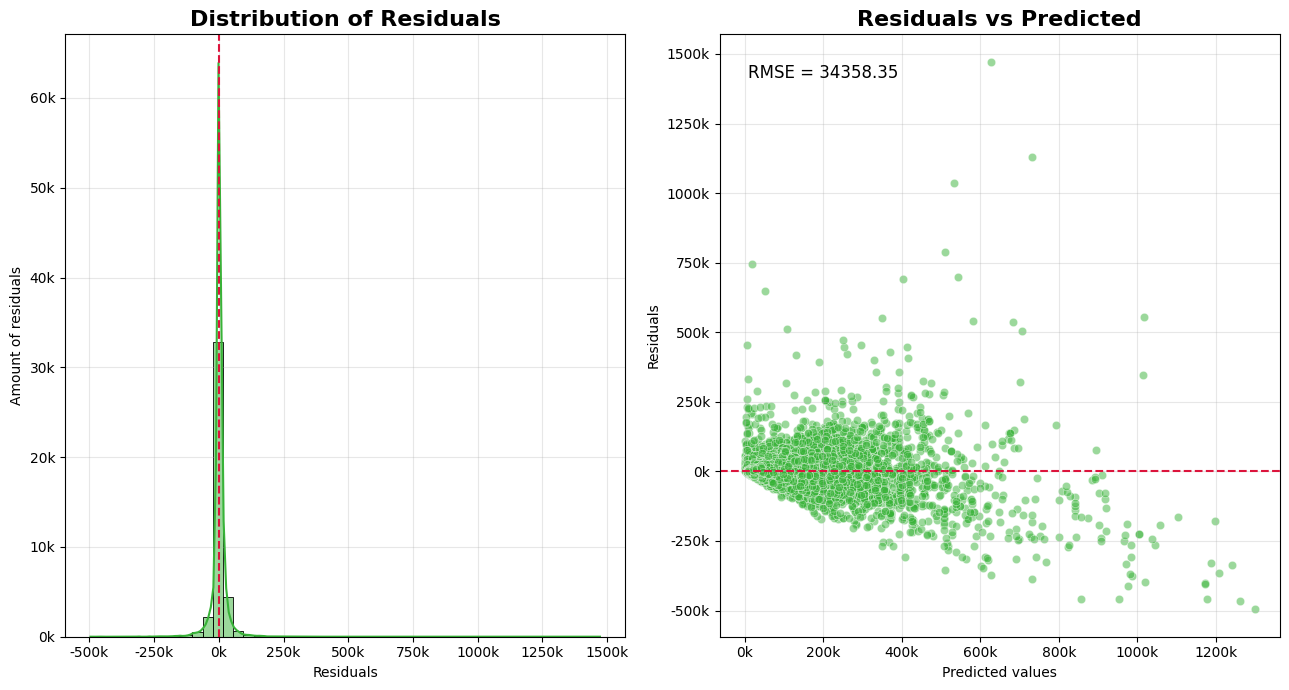

In [ ]:
residuals = y_test - y_test_pred

fig, axes = plt.subplots(1, 2, figsize=(13,7))

# Distribution of residuals
sns.histplot(residuals, bins=50, kde=True, ax=axes[0], color="#38B338")
axes[0].axvline(0, color='crimson', linestyle='--')
axes[0].set_title('Distribution of Residuals', weight='bold', fontsize=16)
axes[0].set_xlabel('Residuals')
axes[0].set_ylabel('Amount of residuals')

axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))
axes[0].grid(True, alpha=0.3)

# Residuals vs predictions
sns.scatterplot(x=y_test_pred, y=residuals, ax=axes[1], alpha=0.5, color="#38B338")
axes[1].axhline(0, color='crimson', linestyle='--')
axes[1].set_title('Residuals vs Predicted', weight='bold', fontsize=16)
axes[1].set_xlabel('Predicted values')
axes[1].set_ylabel('Residuals')

axes[1].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))
axes[1].grid(True, alpha=0.3)

# RMSE annotation
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
axes[1].text(0.05, 0.95, f'RMSE = {rmse:.2f}', transform=axes[1].transAxes,
             va='top', fontsize=12, color='black')

plt.tight_layout()
plt.savefig('../images/model1_residuals_diagnostics.png', dpi=300, bbox_inches='tight')
plt.show()

**Distribution of Residuals**

The residuals exhibit an approximately normal distribution centered around zero, indicating that the model is largely unbiased in its predictions. A slight right skew is visible, reflecting a small number of cases with larger positive errors. Additionally, a limited number of extreme outliers (errors exceeding 500,000 PLN) can be observed, suggesting the presence of atypical vehicles whose prices are more difficult for the model to estimate accurately.

**Residuals vs. Predicted Values**

The scatter of residuals around zero does not reveal a strong systematic pattern, indicating that the main model assumptions generally hold. However, mild heteroscedasticity is present, as the variance of residuals increases for higher predicted prices. Predictions below 100,000 PLN show tighter clustering of errors, while vehicles in the luxury segment (above 250,000 PLN) exhibit a noticeably wider spread of residuals. Overall, the model achieves an RMSE of 36,674 PLN, reflecting moderate predictive performance across the dataset.

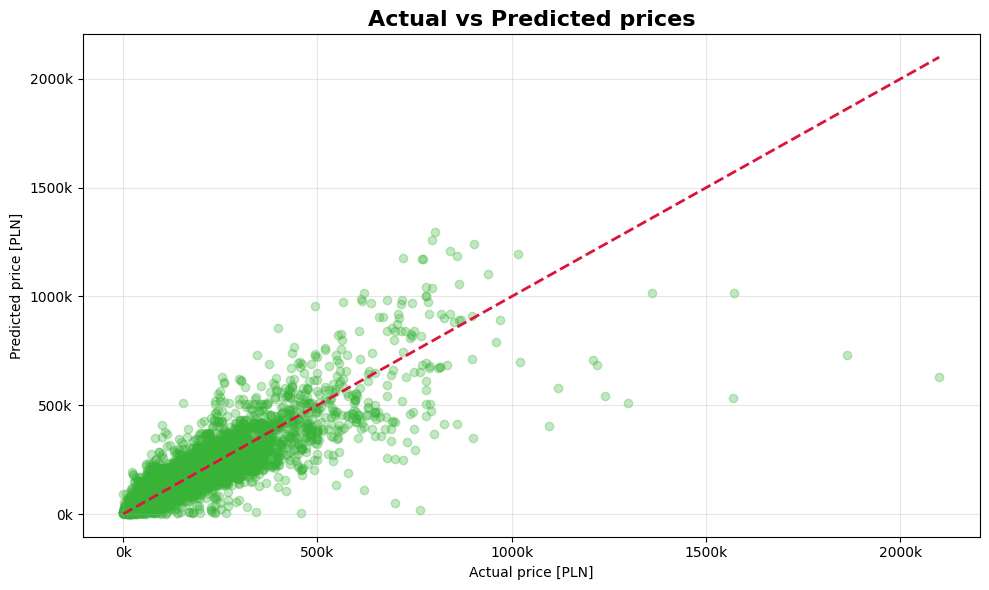

In [ ]:
# Actual vs predicted prices
fig ,ax = plt.subplots(figsize=(10, 6))

ax.scatter(y_test, y_test_pred, alpha=0.3, color="#38B338")
ax.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='crimson',
    linestyle='--',
    linewidth=2
)

ax.set_xlabel('Actual price [PLN]')
ax.set_ylabel('Predicted price [PLN]')
ax.set_title('Actual vs Predicted prices', weight='bold', fontsize=16)
ax.grid(True, alpha=0.3)

ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))

plt.tight_layout()
plt.savefig('../images/model1_actual_vs_predicted', dpi=300, bbox_inches='tight')
plt.show()

**Actual vs Predicted**

Most predictions cluster closely around the ideal reference line, indicating relatively good overall model accuracy across the majority of observations. The dispersion of points is largely symmetric around this line, which suggests that the model does not exhibit a strong systematic bias toward overestimating or underestimating vehicle prices.

A limited number of observations deviate substantially from the reference line, indicating the presence of outliers and cases with higher prediction errors. These instances may correspond to atypical vehicles, such as rare models, supercars, cars with extremely high or low mileage, or vehicles with uncommon feature combinations, which are inherently more difficult for the model to estimate accurately.

Additionally, the spread of points tends to increase for higher price ranges, suggesting that the model performs more consistently for lower and mid-priced vehicles, while predictions for luxury and high-end cars are more variable. This pattern indicates that while the linear regression model captures the general pricing structure of the market reasonably well, it may struggle to fully represent the complex factors influencing prices in the upper segment of the market.

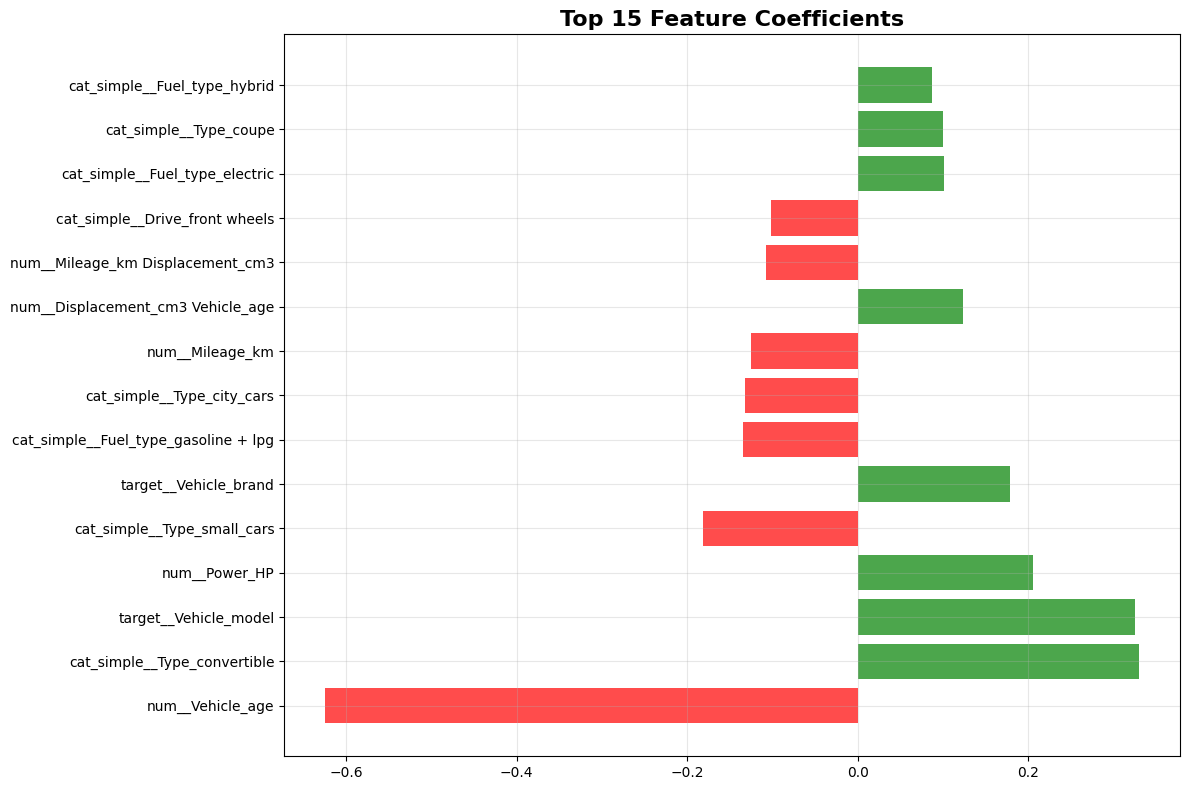

In [ ]:
# Get coefficients
feature_names = best_lin.named_steps['preprocessor'].get_feature_names_out()
coefficients = best_lin.named_steps['model'].coef_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values('Coefficient', key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))

top_15 = importance_df.head(15)
colors = ['green' if c > 0 else 'red' for c in top_15['Coefficient']]
ax.barh(range(len(top_15)), top_15['Coefficient'], color=colors, alpha=0.7)
ax.set_yticks(range(len(top_15)))
ax.set_yticklabels(top_15['Feature'])
ax.set_title('Top 15 Feature Coefficients', weight='bold', fontsize=16)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../images/model1_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

**Feature Importance: Interpretation of Ridge Coefficients**

This chart displays the Top 15 Feature Coefficients from the Ridge Regression model. In a linear model, coefficients represent the direction and magnitude of the relationship between each feature and the target variable (Car Price).

1. The Dominant Factor: Vehicle Age: Strongest Negative Impact: num__Vehicle_age is the most influential feature by a wide margin. Its significant negative coefficient confirms that age is the primary driver of depreciation. As a car gets older, its predicted price drops more sharply than for any other variable change.

2. Key Positive Price Drivers: Body Type & Model: cat_simple__Type_convertible and target__Vehicle_model are the strongest positive predictors. This suggests that convertibles maintain a higher premium in the used market, and the specific model is a powerful indicator of luxury and demand.Performance: num__Power_HP shows a strong positive correlation with price, reinforcing that high-performance vehicles command significantly higher prices.

3. Fuel Type & Efficiency: Eco-Friendly Premium: Both electric and hybrid fuel types show positive coefficients. This indicates that, holding other factors constant, modern green powertrains are valued higher than traditional internal combustion engines. Negative Drivers: Conversely, gasoline + lpg and small/city car types (Type_small_cars, Type_city_cars) have negative coefficients, reflecting their position as budget-friendly or high-depreciation segments.

4. Technical Interactions: Mileage vs. Displacement: The model successfully captured non-linear relationships through interaction terms. For instance, the interaction between Displacement_cm3 and Vehicle_age shows a positive coefficient, likely indicating that large-engine vehicles (often luxury or collector cars) may resist depreciation better than small-engine cars as they age.

The model logic aligns perfectly with real-world automotive economics: Age and Mileage decrease value, while Horsepower and Premium Body Types increase it. The high significance of the Vehicle_model feature justifies the use of Target Encoding to capture brand equity that simple linear features might miss.

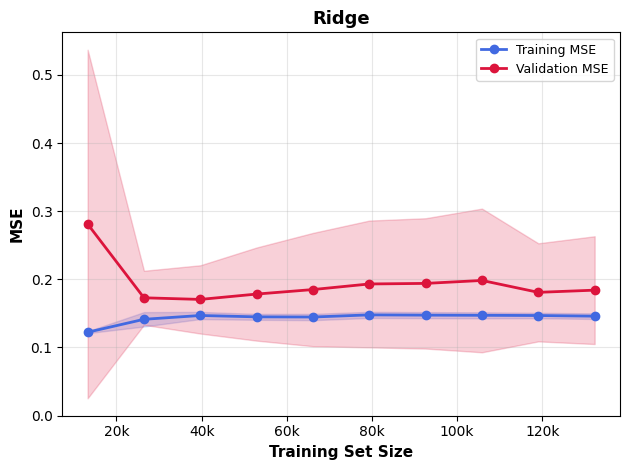

In [ ]:
# Learning curves
def plot_learning_curves(model_dict, X, y, cv=5):
    for idx, (name, model) in enumerate(model_dict.items()):
        
        train_sizes, train_scores, val_scores = learning_curve(
            model, X, y,
            cv=cv,
            n_jobs=-1,
            train_sizes=np.linspace(0.1, 1.0, 10),
            scoring='neg_mean_squared_error',
            random_state=42
        )
        
        train_scores_mean = -train_scores.mean(axis=1)
        train_scores_std = train_scores.std(axis=1)
        val_scores_mean = -val_scores.mean(axis=1)
        val_scores_std = val_scores.std(axis=1)
        
        plt.plot(train_sizes, train_scores_mean, 'o-', color='royalblue', 
                label='Training MSE', linewidth=2, markersize=6)
        plt.fill_between(train_sizes, 
                        train_scores_mean - train_scores_std,
                        train_scores_mean + train_scores_std, 
                        alpha=0.2, color='royalblue')
        
        plt.plot(train_sizes, val_scores_mean, 'o-', color='crimson', 
                label='Validation MSE', linewidth=2, markersize=6)
        plt.fill_between(train_sizes, 
                        val_scores_mean - val_scores_std,
                        val_scores_mean + val_scores_std, 
                        alpha=0.2, color='crimson')
        
        plt.xlabel('Training Set Size', fontsize=11, fontweight='bold')
        plt.ylabel('MSE', fontsize=11, fontweight='bold')
        plt.title(f'{name}', fontsize=13, fontweight='bold')
        plt.legend(loc='best', fontsize=9)
        plt.grid(True, alpha=0.3)

    plt.gca().xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))
    
    plt.tight_layout()
    plt.savefig('../images/model1_learning_curves.png', dpi=300, bbox_inches='tight')
    plt.show()

models_for_learning = {
    'Ridge': grid_log.best_estimator_
}
plot_learning_curves(models_for_learning, X_train, y_train_log, cv=5)

**Learning Curve Analysis**

The learning curves illustrate the relationship between the training set size and the model's performance (MSE). This diagnostic tool helps identify the balance between Bias and Variance.

The curves indicate that the Ridge model suffers from high bias. Both the training and validation errors stabilize at a relatively high level. This suggests that the linear nature of the model, combined with L2 regularization, is too simplistic to capture the full non-linear complexity of the used car market (e.g., brand prestige, depreciation curves, and luxury segments).

A key positive finding is the convergence of the training and validation lines as the sample size increases. The narrow gap between the two curves at the end of the training process demonstrates excellent generalization. This confirms that the model is not overfitting and will perform consistently on new, unseen data.

The pink shaded area represents the variance (confidence interval) of the validation error.

Early Stages: At smaller sample sizes (<25k), we observe high volatility, indicating that the model's performance is highly dependent on the specific data split.

Stabilization: After approximately 25,000–40,000 samples, the variance narrows significantly. This suggests that the dataset size is sufficient to provide a stable and "peaceful" learning environment, making the predictions more robust.

Conclusion: To break through this performance ceiling and reduce the "High Bias" error, the project will transition to high-capacity non-linear models such as Random Forest and XGBoost.

### Conclusions on the Linear Regression Model

The Linear Regression model establishes a strong baseline for subsequent models in this project. It effectively captures general market trends, achieving an ($R^2$) of approximately 0.83, which indicates that about 83% of the variability in car prices can be explained by the selected features. This suggests that a substantial portion of vehicle price variation follows a broadly linear relationship with the predictors used in the model.

In terms of prediction accuracy, the model achieves a Mean Absolute Error (MAE) of approximately 14,797 PLN and a Mean Absolute Percentage Error (MAPE) of around 29.3%. These results indicate a moderate level of predictive accuracy. The model performs reasonably well for standard and older used cars, where price structures tend to be more stable and predictable. However, it proves less reliable for vehicles in the premium and luxury segments.

The relatively high Root Mean Squared Error (RMSE) suggests that the model is strongly affected by outliers and extreme price values. These large deviations significantly penalize the model, indicating that certain vehicles—particularly rare models, supercars, or collector vehicles—are difficult to estimate accurately using a simple linear approach.

Diagnostic analysis also reveals the presence of heteroscedasticity, meaning that the variance of prediction errors increases with higher car prices. As illustrated in the Actual vs. Predicted Values chart, the relationship between predicted and actual prices is not perfectly linear. Consequently, Linear Regression struggles to maintain consistent accuracy across the entire price spectrum, particularly in the upper segments of the market.

Overall, the model performs adequately for mid-range vehicles but tends to underestimate prices for sports cars, luxury vehicles, and older collector cars. This limitation highlights the difficulty of modeling complex market dynamics using purely linear relationships.

To improve predictive performance—especially for high-value and newer vehicles—it is advisable to employ more flexible models capable of capturing non-linear relationships, such as Random Forest or XGBoost.

---

## Second Model - Random Forest



Random Forest is well suited for car price prediction because it can capture complex and nonlinear relationships between vehicle features such as mileage, age, brand, and engine characteristics. Unlike linear models, Random Forest does not assume a fixed functional form and can automatically model feature interactions. It is also robust to outliers and skewed price distributions, which are common in car market data due to the presence of luxury vehicles. Additionally, Random Forest handles both numerical and categorical features effectively after encoding and requires less feature engineering compared to simpler models. Overall, it provides strong predictive performance and good generalization across different price segments.

In [ ]:
# Using preprocessor declared in the feature engineering section
pipeline_rfc = Pipeline([
    ('preprocessor', preprocessor_tree),
    ('model', RandomForestRegressor(random_state=42))
])

In [ ]:
param_dist_rfc = {
    'model__n_estimators': [200, 500],
    'model__max_depth': [10, 15, 20],
    'model__min_samples_leaf': [5, 10, 20],
    'model__min_samples_split': [10, 20],
    'model__max_features': ['sqrt', 0.5],
    'model__max_samples': [0.7, 0.8],
    'model__bootstrap': [True]
}

In [ ]:
kfold_rf = KFold(n_splits=3, shuffle=True, random_state=42)

random_search_rfc = RandomizedSearchCV(
    estimator=pipeline_rfc,
    param_distributions=param_dist_rfc,
    n_iter=12,
    scoring='neg_mean_absolute_error',
    cv=kfold_rf,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

In [ ]:
X_train_clean = X_train.replace([np.inf, -np.inf], np.nan).fillna(0)
X_test_clean = X_test.replace([np.inf, -np.inf], np.nan).fillna(0)

In [ ]:
random_search_rfc.fit(X_train_clean, y_train)

Fitting 3 folds for each of 12 candidates, totalling 36 fits


,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'model__bootstrap': [True], 'model__max_depth': [10, 15, ...], 'model__max_features': ['sqrt', 0.5], 'model__max_samples': [0.7, 0.8], ...}"
,n_iter,12
,scoring,'neg_mean_absolute_error'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [ ]:
best_rfc = random_search_rfc.best_estimator_

y_pred_train_rfc = best_rfc.predict(X_train_clean)
y_pred_test_rfc = best_rfc.predict(X_test_clean)

In [ ]:
# Random forets metrics 
train_metrics_rfc = metrics(y_train, y_pred_train_rfc)
test_metrics_rfc = metrics(y_test, y_pred_test_rfc)
metrics_df_rfc = pd.DataFrame({ 
    'Train': train_metrics_rfc,
    'Test': test_metrics_rfc
})

formatted_df_rfc = metrics_df_rfc.style.format({
    'Train Set': "{:,.4f}" if "R2" in metrics_df_rfc.index else "{:,.2f}",
    'Test Set': "{:,.4f}" if "R2" in metrics_df_rfc.index else "{:,.2f}"
})
metrics_df_rfc

,Train,Test
R2,0.911660,0.938031
RMSE,26585.389810,20776.682179
MAE,6539.983343,8404.628377
MAPE,0.155279,0.199765


The Random Forest Regressor significantly outperforms the baseline Ridge model, increasing the $R^2$ score from approximately 0.831 to 0.938. This improvement indicates that the model captures a much larger portion of the variability in car prices and is better suited for modeling the complex relationships present in the dataset.

**High Predictive Power**

The model achieves a test MAPE of nearly 20%, indicating that it provides relatively accurate price estimates for the majority of vehicle segments. This represents a notable improvement over the linear baseline and suggests that the model captures market dynamics more effectively.

**Good Generalization**

Although the model performs slightly better on the training set (MAE of approximately 3.7k PLN compared to about 8.4k PLN on the test set), the relatively small gap in $R^2$ values suggests that the model generalizes well and does not strongly overfit the training data. Instead, it appears to capture general patterns present in the car market.

**Substantial Error Reduction**

Compared with the linear baseline model, the Mean Absolute Error (MAE) is reduced by roughly 50%. This demonstrates that non-linear ensemble methods such as Random Forest are significantly more effective at capturing complex pricing relationships, including non-linear depreciation patterns and interactions between vehicle features.

Furthermore, the results for the training and test sets are relatively well balanced, which suggests that the model does not exhibit strong overfitting. The slightly higher RMSE observed in one of the datasets may be caused by the presence of several outliers, which naturally increase squared-error-based metrics. However, the remaining evaluation metrics remain within a reasonable range.

Overall, the Random Forest model provides a substantial improvement in predictive performance and confirms that more flexible, non-linear models are better suited for modeling vehicle price dynamics.

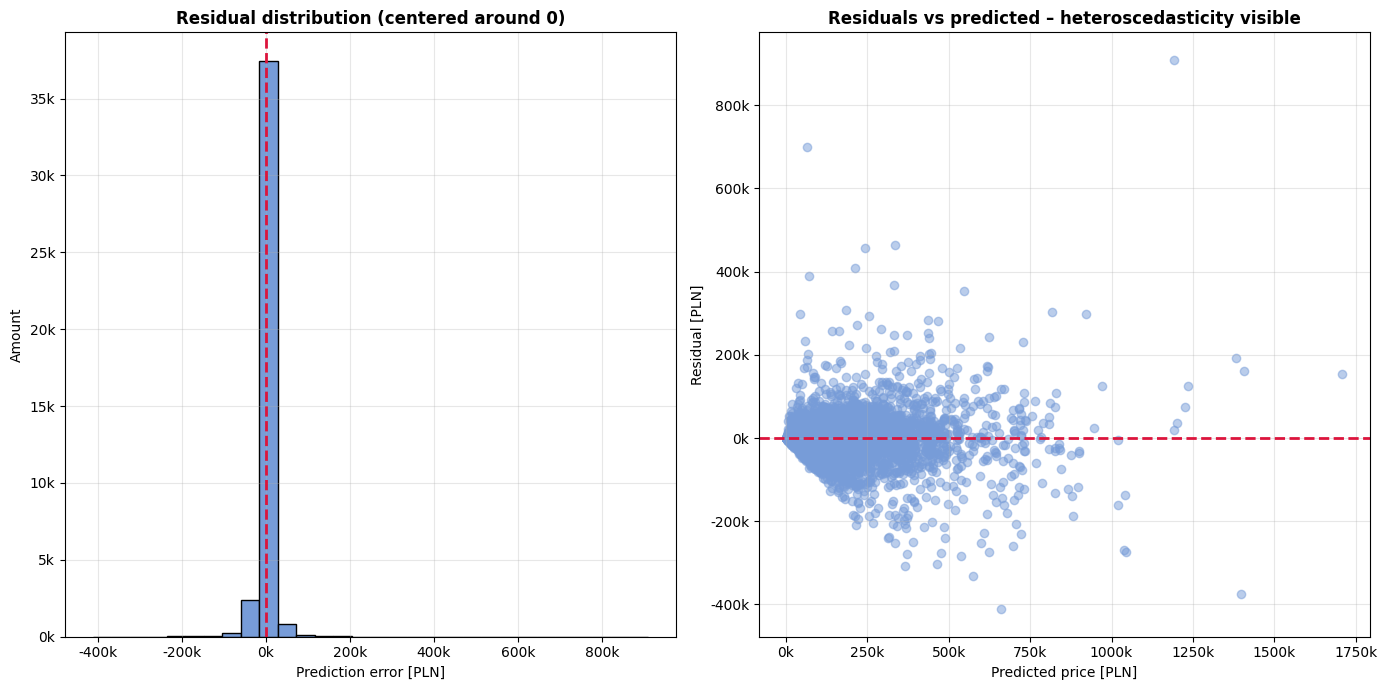

In [ ]:
residuals_rfc = y_test - y_pred_test_rfc

fig, ax = plt.subplots(1, 2, figsize=(14,7))

# Residual distribution (histogram)
ax[0].hist(residuals_rfc, bins=30, color="#779CD8", edgecolor='black')
ax[0].axvline(0, color='crimson', linestyle='--', linewidth=2)
ax[0].set_title('Residual distribution (centered around 0)', weight='bold')
ax[0].set_xlabel('Prediction error [PLN]')
ax[0].set_ylabel('Amount')
ax[0].grid(alpha=0.3)

ax[0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))
ax[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))

# Residuals vs predicted
ax[1].scatter(y_pred_test_rfc, residuals_rfc, alpha=0.5, color="#779CD8")
ax[1].axhline(0, color='crimson', linestyle='--', linewidth=2)
ax[1].set_title('Residuals vs predicted – heteroscedasticity visible', weight='bold')
ax[1].set_xlabel('Predicted price [PLN]')
ax[1].set_ylabel('Residual [PLN]')
ax[1].grid(alpha=0.3)

ax[1].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))
ax[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))

plt.tight_layout()
plt.savefig('../images/model2_residuals_diagnostics_rfc.png', dpi=300, bbox_inches='tight')
plt.show()

The **Distribution of Residuals** shows a strong concentration around zero, with a sharp and narrow peak indicating that most predictions are highly accurate. The overall symmetry of the distribution suggests that the model is largely unbiased and does not exhibit a systematic tendency to either overestimate or underestimate car prices.

The **Residuals vs. Predicted** Values scatter plot also indicates relatively stable error variance, with residuals distributed fairly evenly around the zero line across most price ranges. This pattern suggests that the model maintains consistent prediction quality for a wide range of vehicle prices.

However, several extreme outliers are still visible, with residuals exceeding ±500,000 PLN. These observations likely correspond to rare or atypical vehicles, such as luxury models, collector cars, or highly customized vehicles, whose prices are inherently more difficult to estimate accurately.

Overall, the residual analysis confirms strong model performance with minimal systematic error. Nevertheless, the presence of several extreme deviations suggests that further improvements—such as additional feature engineering, improved handling of rare vehicle categories, or alternative modeling approaches—could help reduce these remaining prediction errors.

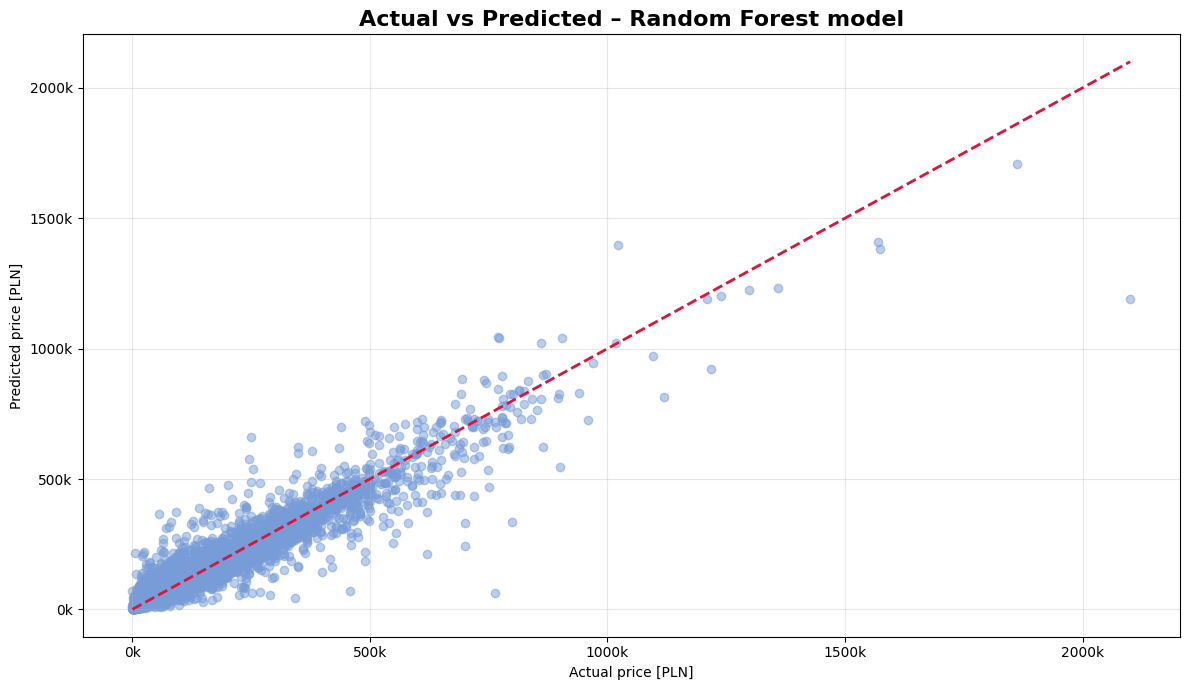

In [ ]:
# Actual vs predicted 
fig, ax = plt.subplots(figsize=(12, 7))

ax.scatter(y_test, y_pred_test_rfc, alpha=0.5, color="#779CD8")
ax.plot([y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        color='crimson', linestyle='--', linewidth=2)

ax.set_xlabel('Actual price [PLN]')
ax.set_ylabel('Predicted price [PLN]')
ax.set_title('Actual vs Predicted – Random Forest model', weight='bold', fontsize=16)

ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))

ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../images/model2_actual_vs_predicted_rfc.png', dpi=300, bbox_inches='tight')
plt.show()

The **Actual vs. Predicted** plot shows a noticeably stronger alignment of observations along the red reference line, indicating a substantial improvement in predictive accuracy compared to the previous model. Most points are tightly clustered around the line, suggesting that the model is able to estimate vehicle prices more precisely across the majority of observations.

Compared with the baseline model, the predictions appear more concentrated and the dispersion of points is smaller, which reflects a reduction in overall prediction error. This improvement indicates that the Random Forest model captures complex, non-linear relationships between features and car prices more effectively.

Although some larger prediction errors are still visible—represented by points located farther from the reference line—their number is significantly lower than in the linear model. These remaining extreme deviations likely correspond to atypical vehicles, such as rare models, luxury cars, or collector vehicles, whose prices are inherently more difficult to estimate.

Further improvements could potentially be achieved through additional hyperparameter tuning, improved feature engineering, or the application of models that are even more robust to outliers. Nonetheless, the current results demonstrate a clear and substantial performance gain over the baseline approach.


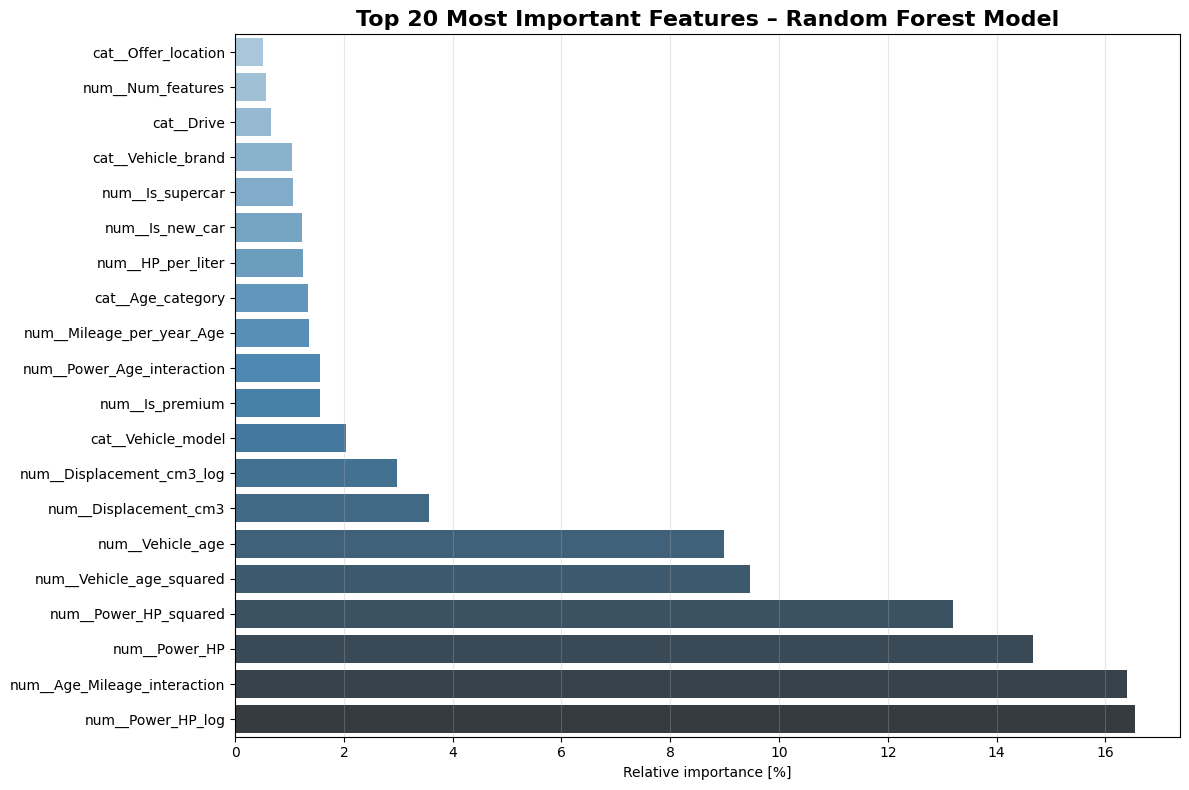

In [ ]:
# Feature importance for Random Forest
model = best_rfc.named_steps['model']
feature_names = best_rfc.named_steps['preprocessor'].get_feature_names_out()

importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': model.feature_importances_
})

top20 = importances.sort_values(by='Importance', ascending=False).head(20)
top20['Importance_pct'] = top20['Importance'] / top20['Importance'].sum() * 100
top20 = top20.sort_values('Importance_pct')

plt.figure(figsize=(12, 8))
ax = sns.barplot(
    x='Importance_pct',
    y='Feature',
    hue='Feature',
    data=top20,
    palette='Blues_d'
)

ax.set_xlabel('Relative importance [%]')
ax.set_ylabel('')
ax.set_title('Top 20 Most Important Features – Random Forest Model', fontsize=16, weight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../images/model2_feature_importance_rfc.png', dpi=300, bbox_inches='tight')
plt.show()

The bar plot above presents the **feature importance** scores for the model. The most influential feature is logarithmic Power_HP, which accounts for over 16% of the total importance. This is followed by Age_mileage_interaction (over 16%) and Power_HP (over 14%). Since these two features are strongly correlated, their importance is distributed between them, reflecting the model’s reliance on different transformations of engine power.

Other important predictors include Power_HP_squared, Vehicle_age, and Vehicle_age_squared which also have a noticeable influence on the predicted price. These variables highlight the importance of both vehicle power and vehicle age in determining car values, as well as the non-linear relationships between these characteristics and price.

The remaining features, such as Num_features, Offer_location, Vehicle_brand, Power_age_intercaction, etc. each contribute less than 4% to the total importance. This suggests that while they still provide useful information to the model, their individual influence on price prediction is relatively limited.

Overall, these results clearly demonstrate that feature engineering plays a crucial role in improving model performance. Creating derived variables and feature transformations allows the model to capture more complex and non-linear relationships in the data, leading to more accurate predictions than relying solely on basic vehicle attributes.

### Conclusions on the Random Forest Model

The Random Forest model significantly outperforms the Linear Regression baseline across all evaluation metrics, demonstrating its strong suitability for car price prediction.

The ($R^2$) score increased from 83% to 93.8%, indicating a much stronger ability to explain the variability in car prices by capturing complex and non-linear relationships between features. Prediction errors were also substantially reduced: the RMSE decreased by approximately 15,000 PLN, while the MAPE dropped from 29.4% to nearly 20%. These improvements result in more accurate and reliable price estimates across most vehicle segments.

Visual diagnostics confirm this improvement. Scatter plots show that predicted prices are much more closely aligned with the actual values compared to the Linear Regression model. The points are more tightly clustered around the reference line, indicating greater stability and accuracy of predictions. Although some deviations still occur—visible in the Actual vs. Predicted scatterplot—the number of extreme errors has been significantly reduced. In a small number of cases, prediction errors still reach several hundred thousand PLN, likely corresponding to rare, luxury, or highly atypical vehicles. These cases could potentially be further improved through additional model refinement or alternative algorithms.

Feature importance analysis highlights that engine power, vehicle age, and production year are among the most influential predictors, which aligns well with real-world automotive pricing dynamics. The residual distribution is tightly centered around zero and largely symmetric, suggesting that the model is relatively unbiased and well-calibrated.

Residuals also remain relatively stable across different price ranges, confirming consistent predictive performance throughout the dataset. Although a small number of extreme outliers remain, the overall robustness and predictive accuracy of the Random Forest model represent a clear and substantial improvement over the linear baseline.

---

## Third Model - XGBoost

XGBoost is a powerful gradient boosting algorithm that is well suited for car price prediction due to its ability to model complex, nonlinear relationships between vehicle attributes and price. By combining many weak decision trees in a sequential manner, XGBoost effectively captures interactions between features such as mileage, vehicle age, engine specifications, and brand.

Additionally, the algorithm is relatively robust to outliers and multicollinearity, which are common characteristics of car pricing datasets. XGBoost also incorporates regularization techniques that help prevent overfitting and improve generalization performance. As a result, it often achieves superior predictive accuracy compared to traditional machine learning models in regression tasks.

In [ ]:
pipeline_xgb = Pipeline([
    ('preprocessor', preprocessor_tree),
    ('model', xgb.XGBRegressor(random_state=42))
])

In [ ]:
# Using Optuna for better hyperparameter tuning
def objective(trial):
    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    cv_scores = []

    params = {
        'n_estimators': 1000, 
        'max_depth': trial.suggest_int('max_depth', 3, 7),
        'min_child_weight': trial.suggest_int('min_child_weight', 5, 20),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.05, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.9),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
        'reg_alpha': trial.suggest_float('reg_alpha',1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'tree_method': 'hist', 
        'early_stopping_rounds': 30, 
        'random_state': 42
    }

    for train_idx, val_idx in kf.split(X_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train_log.iloc[train_idx], y_train_log.iloc[val_idx]

        X_train_tr = preprocessor_tree.fit_transform(X_tr, y_tr)
        X_val_tr = preprocessor_tree.transform(X_val)

        model = xgb.XGBRegressor(**params)
        
        model.fit(
            X_train_tr, y_tr,
            eval_set=[(X_val_tr, y_val)],
            verbose=False
        )

        predict = model.predict(X_val_tr)
        rmse = np.sqrt(mean_squared_error(y_val, predict))
        cv_scores.append(rmse)
        
        trial.report(rmse, step=len(cv_scores))
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return np.mean(cv_scores)

In [ ]:
sampler = optuna.samplers.TPESampler(seed=42)
study = optuna.create_study(direction='minimize', sampler=sampler)
optuna.logging.set_verbosity(optuna.logging.WARNING)
study.optimize(objective, n_trials=50, show_progress_bar=True)

[I 2026-03-08 12:37:58,119] A new study created in memory with name: no-name-83927500-991e-45d7-a418-a060aed69612


  0%|          | 0/50 [00:00<?, ?it/s]

In [ ]:
best_params = study.best_params

final_params = {f'model__{k}': v for k, v in best_params.items()}
final_params['model__n_estimators'] = 1000

pipeline_xgb.set_params(**final_params)

pipeline_xgb.fit(X_train, y_train_log)

y_pred_train_xgb_log = pipeline_xgb.predict(X_train)
y_pred_xgb_log = pipeline_xgb.predict(X_test)
y_pred_xgb = np.expm1(y_pred_xgb_log)
y_pred_train_xgb = np.expm1(y_pred_train_xgb_log)

In [ ]:
# Metrics for XGBoost
train_metrics_xgb = metrics(y_train, y_pred_train_xgb)
test_metrics_xgb = metrics(y_test, y_pred_xgb)

metrics_xgb_df = pd.DataFrame({
    'Metric': train_metrics_xgb.keys(),
    'Train': train_metrics_xgb.values(),
    'Test': test_metrics_xgb.values()
})
metrics_xgb_df

,Metric,Train,Test
0,R2,0.927707,0.942751
1,RMSE,24049.884195,19969.695169
2,MAE,6712.552230,7989.733247
3,MAPE,0.133708,0.168071


The XGBoost model demonstrates slightly better overall performance compared to the Random Forest model. It explains a higher proportion of variance in car prices ($R^2$ = 0.943) and achieves lower prediction errors, with a Root Mean Squared Error (RMSE) of approximately 19,970 PLN and a Mean Absolute Error (MAE) of about 7,990 PLN. Additionally, the lower Mean Absolute Percentage Error (MAPE) value (16.8%) indicates more accurate relative predictions across different price ranges.

Although the performance differences between the two models are relatively small, they remain consistent across all evaluation metrics. Therefore, the XGBoost model can be considered the more reliable choice for this prediction task.

Interestingly, the evaluation metrics obtained on the test set are slightly better than those on the training set. This can occur for several reasons. First, the data distribution after the train–test split may result in the training set containing a greater number of outliers than the test set. Second, the regularization mechanisms used in XGBoost—controlled by parameters such as alpha and gamma—act as filters that help reduce the influence of noise in the training data. As a result, the model may sometimes achieve slightly better performance on the test set.

Overall, the results indicate that the model performs well and effectively captures the underlying patterns present in the data. As a tree-based algorithm, XGBoost is capable of modeling complex nonlinear relationships between features and the target variable.

Further improvements could be achieved through a more detailed error analysis. In particular, it would be useful to identify which vehicles generate the largest prediction errors and determine whether specific market segments or feature combinations contribute to these inaccuracies.

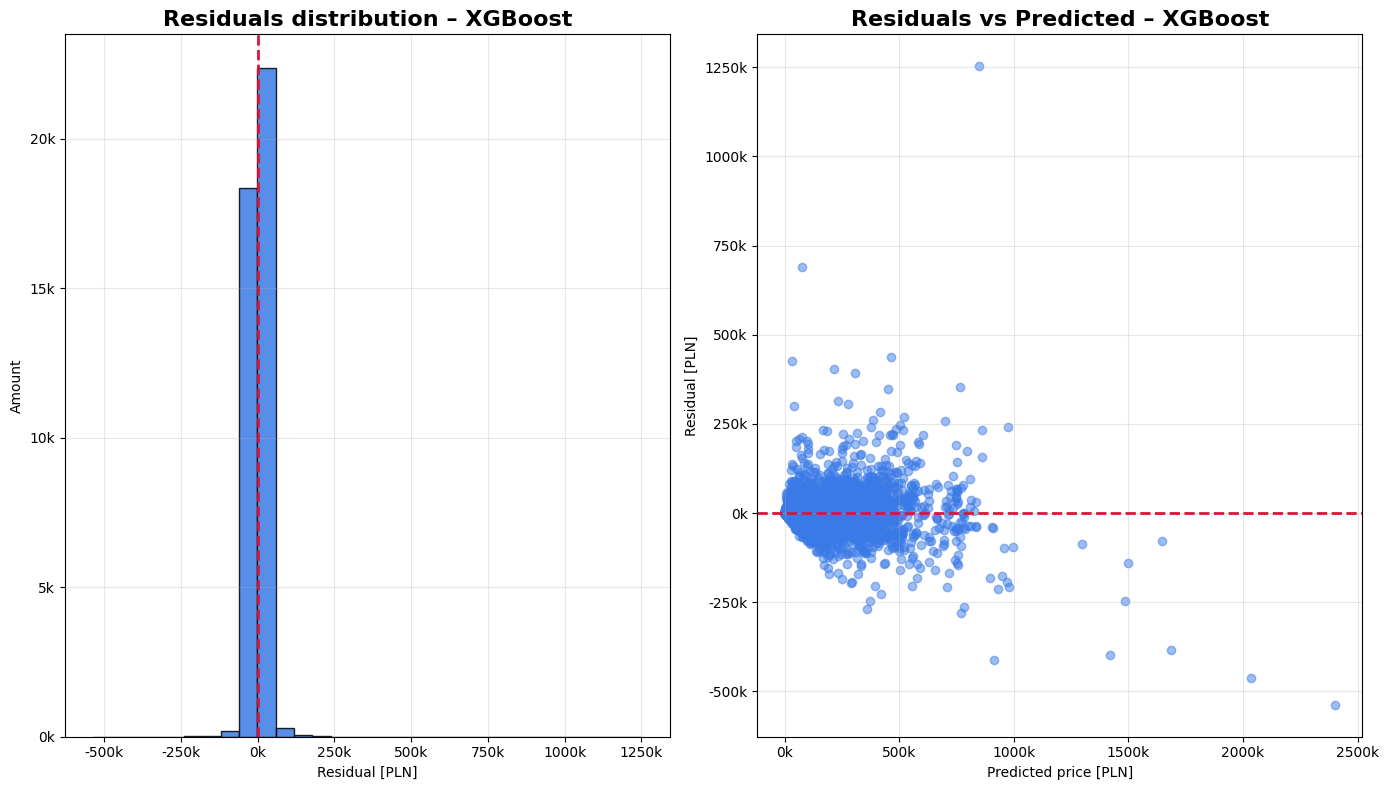

In [ ]:
residuals_xgb = y_test - y_pred_xgb

fig, ax = plt.subplots(1, 2, figsize=(14, 8))

# Distribution of residuals
ax[0].hist(residuals_xgb, bins=30, color="#3A7AE7", edgecolor='black', alpha=0.85)
ax[0].axvline(0, color='crimson', linestyle='--', linewidth=2)
ax[0].set_title("Residuals distribution – XGBoost", fontsize=16, weight='bold')
ax[0].set_xlabel("Residual [PLN]")
ax[0].set_ylabel("Amount")
ax[0].grid(alpha=0.3)

ax[0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))
ax[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))

# Scatter residuals vs predicted
ax[1].scatter(y_pred_xgb, residuals_xgb, alpha=0.5, color="#3A7AE7")
ax[1].axhline(0, color='crimson', linestyle='--', linewidth=2)
ax[1].set_title("Residuals vs Predicted – XGBoost", fontsize=16, weight='bold')
ax[1].set_xlabel("Predicted price [PLN]")
ax[1].set_ylabel("Residual [PLN]")
ax[1].grid(alpha=0.3)

ax[1].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))
ax[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))

plt.tight_layout()
plt.savefig('../images/model3_residuals_diagnostics_xgb.png', dpi=300, bbox_inches='tight')
plt.show()

**Distribution of Residuals**

The histogram shows that the residuals are tightly centered around zero, indicating that the model is generally unbiased and performs accurately for the majority of observations. The distribution is highly peaked, meaning that most prediction errors are small and fall within a narrow range around zero.

However, a slight right skew with a long positive tail is visible. This suggests that while the model typically produces accurate predictions, there are certain cases in which it significantly underestimates the actual price, resulting in large positive residuals. These cases likely correspond to rare or unusually expensive vehicles that differ from typical observations in the dataset.

**Residuals vs. Predicted**

The scatter plot of residuals versus predicted values reveals a pattern of Heteroscedasticity, indicating that the variance of prediction errors increases as the predicted price becomes larger.

This can be observed in the characteristic “fanning out” pattern: residuals remain tightly clustered around the zero line for lower predicted prices but become increasingly dispersed for higher predicted values. Additionally, several noticeable outliers appear far above the zero line, confirming that the model has greater difficulty accurately predicting the prices of the most expensive or unusual vehicles.

Overall, while the model performs very well for the majority of typical cars, prediction uncertainty increases in the higher price segments.

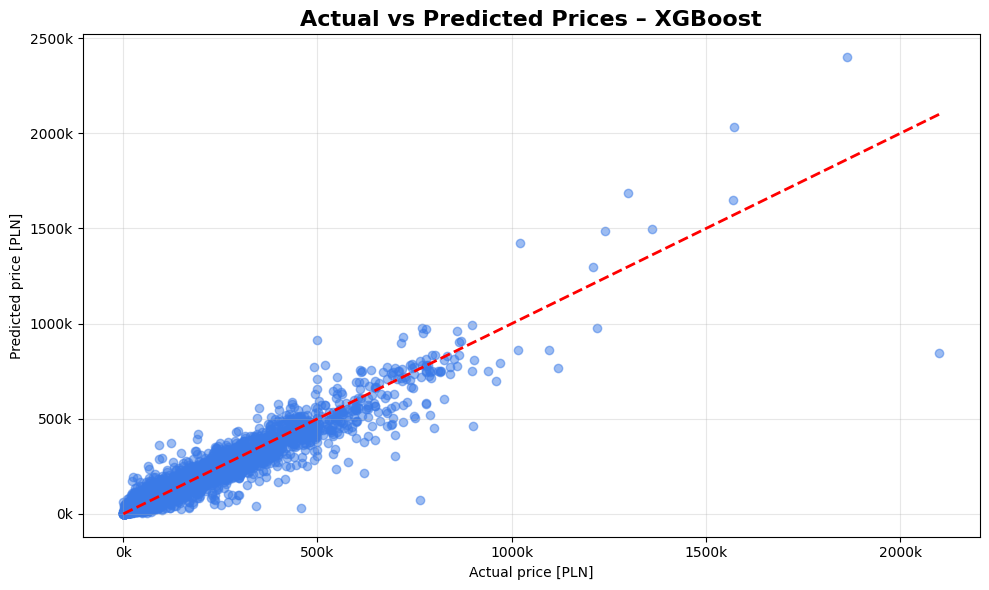

In [ ]:
# Actual vs predicted prices
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(y_test, y_pred_xgb, alpha=0.5, color="#3A7AE7")
ax.plot([y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        'r--', linewidth=2)

ax.set_xlabel("Actual price [PLN]")
ax.set_ylabel("Predicted price [PLN]")
ax.set_title("Actual vs Predicted Prices – XGBoost", fontsize=16, weight='bold')
ax.grid(alpha=0.3)

ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))

plt.tight_layout()
plt.savefig('../images/model3_actual_vs_predicted_rfc', dpi=300, bbox_inches='tight')
plt.show()

The **Actual vs. Predicted Prices** plot shows a strong linear relationship for values below 1 million PLN, where most data points lie close to the red dashed reference line. This indicates high model accuracy for the majority of observations within the typical price range.

However, for prices above approximately 1.5 million PLN, the points begin to fall noticeably below the reference line. This pattern suggests that the model tends to underestimate the prices of the most expensive or rare vehicles.

Overall, the model performs very well for the majority of cars in the dataset, but its predictive accuracy decreases for extreme high-value cases. This behavior likely reflects the limited number of such vehicles in the dataset as well as the greater complexity of pricing in the luxury segment, where factors such as rarity, brand prestige, and vehicle condition may play a larger role.

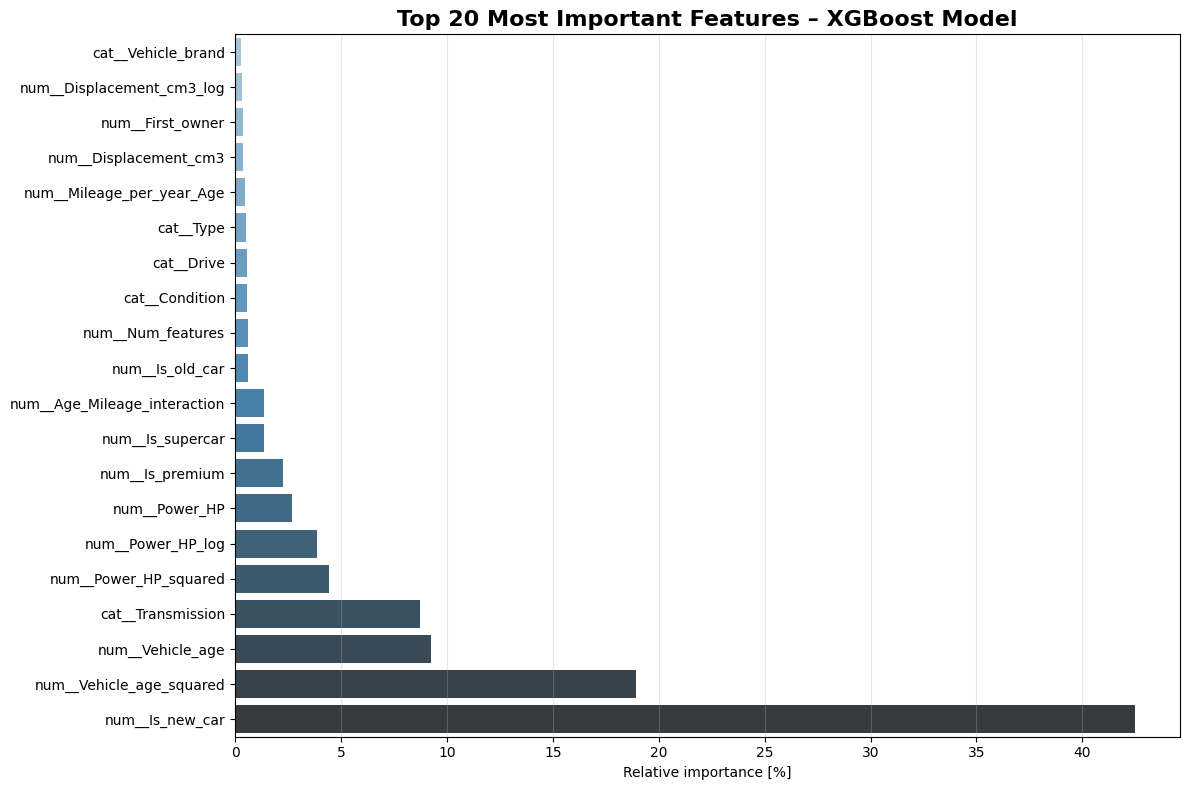

In [ ]:
# Feature importance for XGBoost
model = pipeline_xgb.named_steps['model']
preprocessor = pipeline_xgb.named_steps['preprocessor'].get_feature_names_out()

importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': model.feature_importances_
})

top20 = importances.sort_values(by='Importance', ascending=False).head(20)
top20['Importance_pct'] = top20['Importance'] / top20['Importance'].sum() * 100
top20 = top20.sort_values('Importance_pct') 

plt.figure(figsize=(12,8))
ax = sns.barplot(
    x='Importance_pct',
    y='Feature',
    hue='Feature',
    data=top20,
    palette='Blues_d'
)

ax.set_xlabel('Relative importance [%]')
ax.set_ylabel('')
ax.set_title('Top 20 Most Important Features – XGBoost Model', fontsize=16, weight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../images/model3_feature_importance_xgb.png', dpi=300, bbox_inches='tight')
plt.show()

The chart above presents the **feature importance** for the XGBoost model. The most influential feature is Is_new_car, with an importance score of approximately 42%, indicating that this variable has a substantially greater impact on the model’s predictions than the remaining features, exceeding their importance by several times.

The second most important feature is Vehicle_age_squared, which is closely related to vehicle age and helps capture the non-linear relationship between age and price. This feature has slightly lower importance, followed by Vehicle_age, with these variables contributing approximately 19% and 9% to the model. The prominence of these age-related variables suggests that vehicle depreciation is one of the primary drivers of price variation in the dataset.

Another important feature is Transmission, accounting for nearly 9% of the total importance, indicating that the type of gearbox also has a meaningful impact on vehicle valuation. Additionally, variables related to Power_HP reach a moderate importance level of around 3–4%, suggesting that engine performance also plays a role in price determination.

In contrast, features such as vehicle amenities, brand, fuel type, and engine displacement contribute relatively little to the model’s predictions, each representing only a small fraction of the total importance.

Overall, these results suggest that core vehicle characteristics related to age and mechanical configuration dominate price estimation, while auxiliary features play a smaller supporting role in determining vehicle prices.

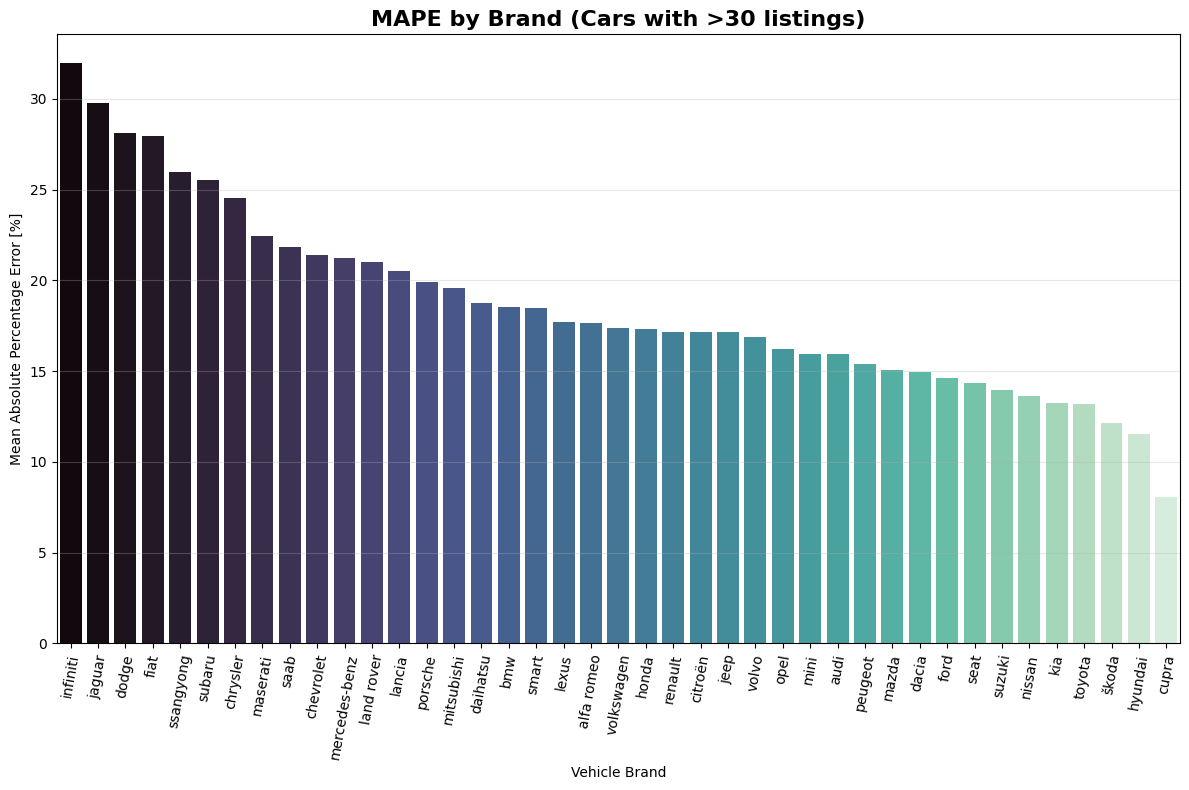

In [ ]:
# Make a division to visualize MAPE in popular vs rare cars
test_df = X_test.copy()
test_df['actual'] = y_test
test_df['predicted'] = y_pred_xgb
test_df['error'] = np.abs(test_df['actual'] - test_df['predicted'])
test_df['error_pct'] = test_df['error'] / test_df['actual'] * 100

error_by_brand = test_df.groupby('Vehicle_brand')['error_pct'].agg(['mean', 'count']).sort_values(by='mean', ascending=False)
error_by_brand = error_by_brand[error_by_brand['count'] > 30]  

plt.figure(figsize=(12, 8))
error_by_brand_sorted = error_by_brand.sort_values('mean', ascending=False).reset_index()

ax = sns.barplot(
    data=error_by_brand_sorted,
    x='Vehicle_brand',
    y='mean',
    hue='Vehicle_brand',
    palette='mako'
)

plt.xticks(rotation=80)
plt.title('MAPE by Brand (Cars with >30 listings)', fontsize=16, weight='bold')
plt.ylabel('Mean Absolute Percentage Error [%]')
plt.xlabel('Vehicle Brand')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../images/model3_MAPE_by_brand.png', dpi=300, bbox_inches='tight')
plt.show()

The bar plot indicates that the **Mean Absolute Percentage Error** (MAPE) increases for more specific and less common car brands. Infiniti shows the highest error, exceeding 31%, which can be explained by its status as a premium brand with relatively high prices and limited market availability compared to mass-market brands such as BMW, Audi, Mercedes-Benz, Opel, and Toyota.

A similar pattern can be observed for other luxury or niche brands, including Jaguar, Dodge, and Subaru, where the smaller number of observations makes accurate price prediction more challenging. Limited data reduces the model’s ability to learn consistent pricing patterns for these vehicles.

Additionally, brands such as Daihatsu, Lancia, and Saab are no longer widely present in new car production, and the vehicles that remain on the market are often older or in poorer condition. This introduces additional variability in prices and further complicates accurate prediction.

In contrast, cars from mass-market brands such as BMW, Audi, Mazda, and Kia show a much lower MAPE, typically ranging between 12% and 18%, which can be considered an acceptable level of prediction error for this type of model.

Overall, these results suggest that model performance strongly depends on data availability and market consistency. Brands with larger datasets and more stable pricing patterns allow the model to learn more accurate relationships, whereas rare or niche brands introduce higher prediction uncertainty.

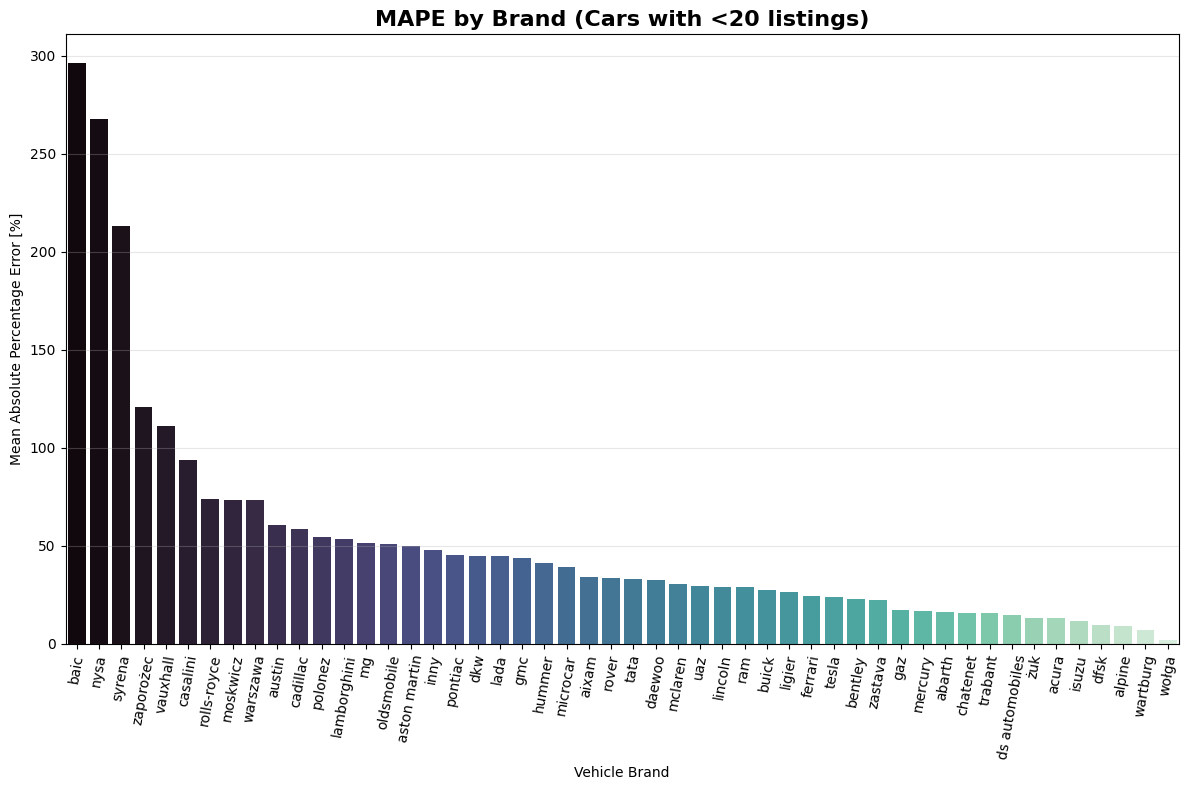

In [ ]:
# Make a division to visualize MAPE in popular vs rare cars v2
test_df = X_test.copy()
test_df['actual'] = y_test
test_df['predicted'] = y_pred_xgb
test_df['error'] = np.abs(test_df['actual'] - test_df['predicted'])
test_df['error_pct'] = test_df['error'] / test_df['actual'] * 100

error_by_brand = test_df.groupby('Vehicle_brand')['error_pct'].agg(['mean', 'count']).sort_values(by='mean', ascending=False)
error_by_brand = error_by_brand[error_by_brand['count'] < 30]  

plt.figure(figsize=(12, 8))
error_by_brand_sorted = error_by_brand.sort_values('mean', ascending=False).reset_index()

ax = sns.barplot(
    data=error_by_brand_sorted,
    x='Vehicle_brand',
    y='mean',
    hue='Vehicle_brand',
    palette='mako'
)

plt.xticks(rotation=80)
plt.title('MAPE by Brand (Cars with <20 listings)', fontsize=16, weight='bold')
plt.ylabel('Mean Absolute Percentage Error [%]')
plt.xlabel('Vehicle Brand')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../images/model3_MAPE_by_brandv2.png', dpi=300, bbox_inches='tight')
plt.show()

In contrast to the previous **MAPE bar plot**, this chart reveals a different and more interesting distribution of prediction errors across car brands. The highest MAPE values are observed for very old vehicles, typically collector cars that are more than 30 years old, such as Polonez, Warszawa, Nysa, and Syrena. For these models, the prediction error ranges from approximately 50% to over 250%.

These extremely high errors are likely caused by the limited number of observations, large differences in vehicle condition, and the collector value that often depends on subjective factors such as rarity, restoration quality, and historical significance.

In contrast, modern luxury and sports car brands, including McLaren, Ferrari, Bentley, and Aston Martin, exhibit substantially lower prediction errors, generally below 50%. However, some premium brands such as Rolls-Royce and Lamborghini still show errors exceeding slightly 50%, which may result from the relatively small sample size or large price variability within these brands.

Overall, the results suggest that very old vehicles introduce significant uncertainty into the model due to their highly variable and often non-standard pricing mechanisms. Further analysis may be required to determine whether these cars should be modeled separately, filtered, or handled with additional features (e.g., collector status, rarity indicators) to improve the model’s overall predictive performance.

## Error Analysis and Model Refinement

The previously presented chart indicates that rare and niche vehicles, such as Syrena, Warszawa, and Nysa, as well as high-end supercars including Lamborghini, Aston Martin, and Rolls-Royce, contribute disproportionately to the prediction errors of the model. These vehicles represent atypical segments of the market, characterized by limited observations and highly variable pricing patterns.

While the model demonstrates strong predictive performance for mass-market vehicles, it struggles to accurately estimate prices for rare, luxury, or collector cars. This limitation likely arises from the small number of observations and the unique pricing mechanisms associated with such vehicles.

In this section, a more detailed error analysis is conducted to identify which specific vehicles and market segments generate the largest prediction errors. The goal is to better understand the underlying causes of these inaccuracies and explore potential strategies to mitigate their impact on the overall model performance.

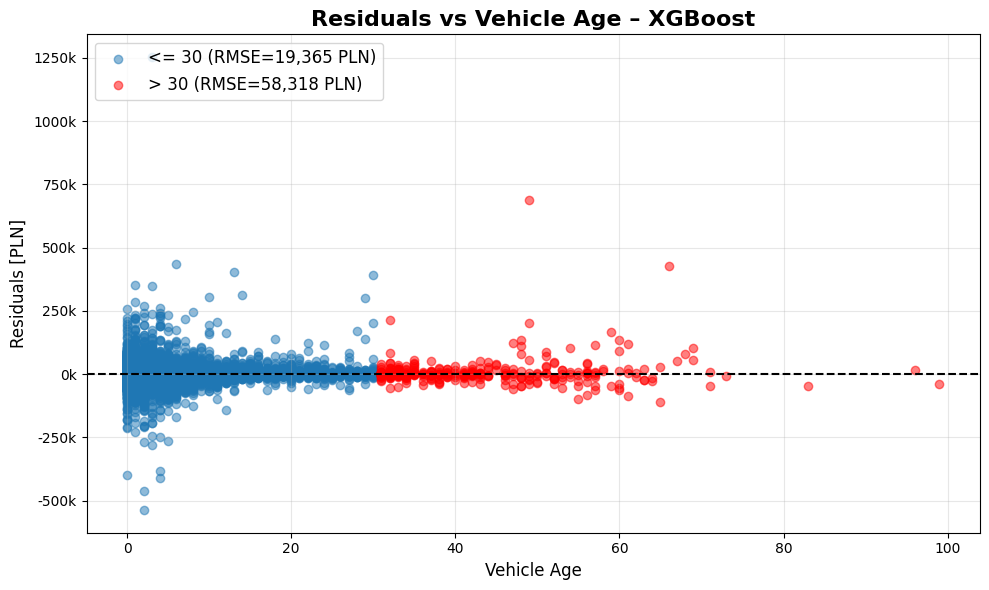

In [ ]:
# Resiudals vs vehicle age
ages = X_test['Vehicle_age'].values
old_mask = ages > 30

rmse_old = np.sqrt(mean_squared_error(y_test[old_mask], y_pred_xgb[old_mask]))
rmse_new = np.sqrt(mean_squared_error(y_test[~old_mask], y_pred_xgb[~old_mask]))

plt.figure(figsize=(10, 6))

plt.scatter(ages[~old_mask], residuals_xgb[~old_mask],
            alpha=0.5, label=f'<= 30 (RMSE={rmse_new:,.0f} PLN)')

plt.scatter(ages[old_mask], residuals_xgb[old_mask],
            color='red', alpha=0.5, label=f'> 30 (RMSE={rmse_old:,.0f} PLN)')

plt.axhline(0, color='black', linestyle='--', linewidth=1.5)
plt.xlabel('Vehicle Age', fontsize=12)
plt.ylabel('Residuals [PLN]', fontsize=12)
plt.title('Residuals vs Vehicle Age – XGBoost', fontsize=16, weight='bold')

plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))
plt.grid(alpha=0.3)
plt.legend(loc='upper left', fontsize=12)

plt.tight_layout()
plt.savefig('../images/corrected_residuals_vs_year_of_production_xgb_before_cleaning.png', dpi=300, bbox_inches='tight')
plt.show()

The **scatter plot** confirms the relationship between vehicle age and prediction errors. Cars older than 30 years tend to exhibit higher residuals, which is consistent with the results observed in the MAPE analysis. Although the number of such vehicles in the dataset is relatively small, cars manufactured between 1960 and 1980 are frequently overestimated by the model. This likely reflects the difficulty of predicting prices for collector or rare vehicles, whose market value is often influenced by historical significance, rarity, and individual condition.

In addition, modern supercars such as Ferrari, Bentley, and Lamborghini also display relatively high MAPE values and large residuals. These brands are represented by only a limited number of observations in the dataset, while their prices are extremely high compared to typical vehicles. As a result, the model may struggle to correctly learn brand-specific pricing patterns for these luxury segments.

The RMSE analysis further supports these findings. Vehicles younger than 30 years show a relatively low RMSE, slightly better than the overall RMSE of the XGBoost model (19,365 PLN). In contrast, vehicles older than 30 years exhibit a substantially higher RMSE of approximately 58,318 PLN, which is about three times larger than the error observed for newer vehicles.

Overall, these results suggest that additional feature engineering may help improve the model’s performance. Creating new variables that explicitly capture characteristics such as collector status, vehicle rarity, or membership in the luxury segment could allow the model to better represent these complex pricing mechanisms and reduce prediction errors for both very old and high-end vehicles.

As discussed earlier, additional feature engineering was required to help the tuned model better capture exceptional relationships present in the dataset, particularly those associated with rare or atypical vehicles.

First, I introduced brand category features and assigned them specific weights in order to highlight brands that previously generated the largest prediction errors. These include both rare domestic collector vehicles (e.g., Syrena, Nysa, Warszawa) and high-end luxury brands (e.g., Lamborghini and Rolls-Royce). By explicitly marking these categories, the model is encouraged to treat such observations with greater attention during the learning process.

Additionally, a brand frequency feature was created to indicate how common or rare each brand is within the dataset. This variable provides the model with information about the relative representation of brands, which may help distinguish between mass-market vehicles and rare or niche models.

The preprocessing pipeline was also refined to ensure that the model properly handles both numerical and categorical variables. In particular, the preprocessing step was adjusted to improve the treatment of categorical features, and a smoothing parameter of 500 was introduced to provide stronger regularization and reduce the risk of overfitting.

Finally, several hyperparameters were slightly adjusted within the objective_tuned function to make the model more conservative and improve generalization performance. These adjustments were intended to maintain strong predictive accuracy while reducing the likelihood of overfitting.

In [ ]:
def get_brand_reliability_category(brand):
    # Defining brand categories
    brand_lower = str(brand).lower() 
    
    luxury = ['ferrari', 'lamborghini', 'rolls-royce', 'bentley', 'aston martin', 
              'mclaren', 'maserati', 'porsche', 'lotus']
    american = ['ram', 'dodge', 'chevrolet', 'hummer', 'cadillac']
    vintage = ['syrena', 'nysa', 'warszawa', 'polonez', 'żuk', 'gaz', 
               'moskwicz', 'lada', 'wartburg', 'trabant', 'tata']
    premium_asian = ['infiniti', 'acura', 'baic', 'ssangyong']
    budget = ['dacia', 'fiat', 'daewoo', 'lancia']
    
    if brand_lower in luxury: 
        return 'Luxury'
    elif brand_lower in american: 
        return 'American'
    elif brand_lower in vintage: 
        return 'Vintage'
    elif brand_lower in premium_asian: 
        return 'Premium_Asian'
    elif brand_lower in budget: 
        return 'Budget'
    else: 
        return 'Standard'

X_train['Brand_category'] = X_train['Vehicle_brand'].apply(get_brand_reliability_category)
X_test['Brand_category'] = X_test['Vehicle_brand'].apply(get_brand_reliability_category)

In [ ]:
brand_freq = X_train['Vehicle_brand'].value_counts().to_dict()
X_train['Brand_frequency'] = X_train['Vehicle_brand'].map(brand_freq)
X_test['Brand_frequency'] = X_test['Vehicle_brand'].map(brand_freq).fillna(0)

# Brand popularity bins
bins = [0, 10, 50, 200, float('inf')]
labels = ['Rare', 'Uncommon', 'Common', 'Popular']

X_train['Brand_popularity'] = pd.cut(X_train['Brand_frequency'], bins=bins, labels=labels)
X_test['Brand_popularity'] = pd.cut(X_test['Brand_frequency'], bins=bins, labels=labels)

In [ ]:
# Add some weights to brands below
weight_map = {
    'Vintage': 1.5,      
    'Premium_Asian': 1.4,
    'Luxury': 1.2,       
    'American': 1.2,     
    'Budget': 1.1,      
    'Standard': 1.0    
}

sample_weights_balanced = np.ones(len(X_train))

for category, weight in weight_map.items():
    mask = X_train['Brand_category'] == category
    sample_weights_balanced[mask] = weight

# Additional penalty for very rare brands
rare_mask = X_train['Brand_frequency'] < 20
sample_weights_balanced[rare_mask] = np.minimum(sample_weights_balanced[rare_mask] * 0.5, 0.5)

In [ ]:
num_cols_enhanced = num_cols + ['Brand_frequency']
cat_cols_simple_enhanced = cat_cols_simple + ['Brand_category', 'Brand_popularity']

# New preprocessor for tunned XGboost
preprocessor_enhanced = ColumnTransformer([
    ('num', StandardScaler(), num_cols_enhanced),
    ('target', TargetEncoder(smoothing=500), cat_cols_to_encode), 
    ('cat_simple', OneHotEncoder(handle_unknown='ignore'), cat_cols_simple_enhanced)
])

In [ ]:
def objective_tuned(trial):
    # Split data with stratification to preserve index mapping
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train, 
        y_train_log, 
        test_size=0.2, 
        random_state=42
    )
    
    # Get weights using .loc to preserve pandas index alignment
    sw_tr = pd.Series(sample_weights_balanced, index=X_train.index).loc[X_tr.index].values
    sw_val = pd.Series(sample_weights_balanced, index=X_train.index).loc[X_val.index].values
    
    params = {
        'n_estimators': 2000,
        'max_depth': trial.suggest_int('max_depth', 3, 6),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.05, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 0.8),
        'reg_alpha': trial.suggest_float('reg_alpha',1.0, 100.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1.0, 100.0, log=True),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 0.7),
        'min_child_weight': trial.suggest_int('min_child_weight', 3, 10),
        'gamma': trial.suggest_float('gamma', 0.1, 1.0),
        'tree_method': 'hist',
        'random_state': 42
    }
    
    X_tr_tf = preprocessor_enhanced.fit_transform(X_tr, y_tr)
    X_val_tf = preprocessor_enhanced.transform(X_val)
    
    model = xgb.XGBRegressor(**params, early_stopping_rounds=50)
    model.fit(
        X_tr_tf, y_tr, 
        eval_set=[(X_val_tf, y_val)], 
        sample_weight=sw_tr,
        verbose=False
    )
    
    trial.set_user_attr("best_iter", model.best_iteration)
    
    # Return validation RMSE
    y_val_pred = model.predict(X_val_tf)
    return np.sqrt(mean_squared_error(y_val, y_val_pred, sample_weight=sw_val))

In [ ]:
sampler = optuna.samplers.TPESampler(seed=42)
study_tun = optuna.create_study(direction='minimize', sampler=sampler)
optuna.logging.set_verbosity(optuna.logging.WARNING)

study_tun.optimize(objective_tuned, n_trials=50, show_progress_bar=True)

  0%|          | 0/50 [00:00<?, ?it/s]

In [ ]:
best_params_hybrid = study.best_params
best_n_estimators_hybrid = 2000

pipeline_final = Pipeline([
    ('preprocessor', preprocessor_enhanced),
    ('model', xgb.XGBRegressor(**best_params_hybrid, n_estimators=best_n_estimators_hybrid, random_state=42))
])

pipeline_final.fit(X_train, y_train_log, model__sample_weight=sample_weights_balanced)
y_pred_final = np.expm1(pipeline_final.predict(X_test))
y_train_pred_final = np.expm1(pipeline_final.predict(X_train))

In [ ]:
# Mtrics for tunned XGBoost model
test_metrics_xgb_cleaned = metrics(y_test, y_pred_final)
train_metrics_xgb_cleaned = metrics(y_train, y_train_pred_final)

metrics_xgb_cleaned = pd.DataFrame({
    'Metric': train_metrics_xgb_cleaned.keys(),
    'Train': train_metrics_xgb_cleaned.values(),
    'Test': test_metrics_xgb_cleaned.values()
})
metrics_xgb_cleaned

,Metric,Train,Test
0,R2,0.922878,0.924599
1,RMSE,24840.242917,22917.965124
2,MAE,6847.425832,8062.047185
3,MAPE,0.140738,0.172077


The model demonstrates strong overall performance, achieving an R² score of 92.3%. Although this value is slightly lower than the XGBoost model before the cleaning process, it is important to note that the train and test R² scores are very similar. This indicates that the model generalizes well to unseen data and does not suffer significantly from overfitting.

The RMSE of 22,918 PLN suggests that larger prediction errors still occur, primarily for high-priced or rare vehicles, as illustrated in the charts presented earlier. Although this value may initially appear large, it should be interpreted in the context of the dataset, where vehicle prices range from approximately few hundred PLN to several million PLN. Within this scale, the RMSE remains relatively reasonable.

The MAE of 8,062 PLN indicates that, on average, the model’s predictions deviate from the actual prices by approximately eight thousand PLN.

A MAPE of 17.2% shows that relative prediction errors remain moderate and acceptable for this type of market data, where prices can vary substantially depending on vehicle condition, rarity, and specifications.

Overall, the model performs reliably but still struggles with extreme or niche cases. Importantly, the evaluation metrics for both the training and test sets remain well balanced, suggesting stable model performance and good generalization. Considering the inherent variability of the car market, these results can be regarded as satisfactory.

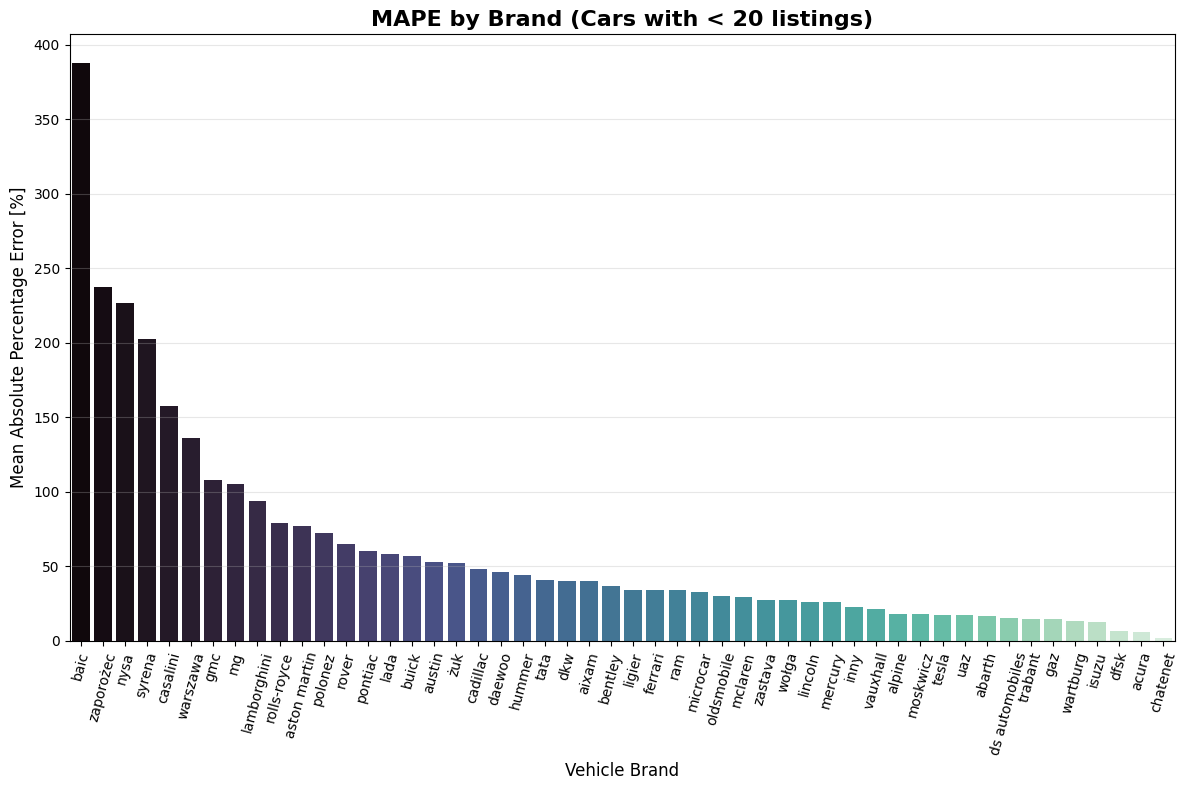

In [ ]:
# Check which cars have changed their MAPE
test_df = X_test.copy()
test_df['actual'] = y_test
test_df['predicted'] = y_pred_final
test_df['error'] = np.abs(test_df['actual'] - test_df['predicted'])
test_df['error_pct'] = test_df['error'] / test_df['actual'] * 100

error_by_brand = test_df.groupby('Vehicle_brand')['error_pct'].agg(['mean', 'count']).sort_values(by='mean', ascending=False)
error_by_brand = error_by_brand[error_by_brand['count'] < 30]  

plt.figure(figsize=(12, 8))
error_by_brand_sorted = error_by_brand.sort_values('mean', ascending=False).reset_index()

ax = sns.barplot(
    data=error_by_brand_sorted,
    x='Vehicle_brand',
    y='mean',
    hue='Vehicle_brand',
    palette='mako'
)

plt.xticks(rotation=75)
plt.title('MAPE by Brand (Cars with < 20 listings)', fontsize=16, weight='bold')
plt.ylabel('Mean Absolute Percentage Error [%]', fontsize=12)
plt.xlabel('Vehicle Brand', fontsize=12)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../images/tuned_model_MAPE_by_brand.png', dpi=300, bbox_inches='tight')
plt.show()

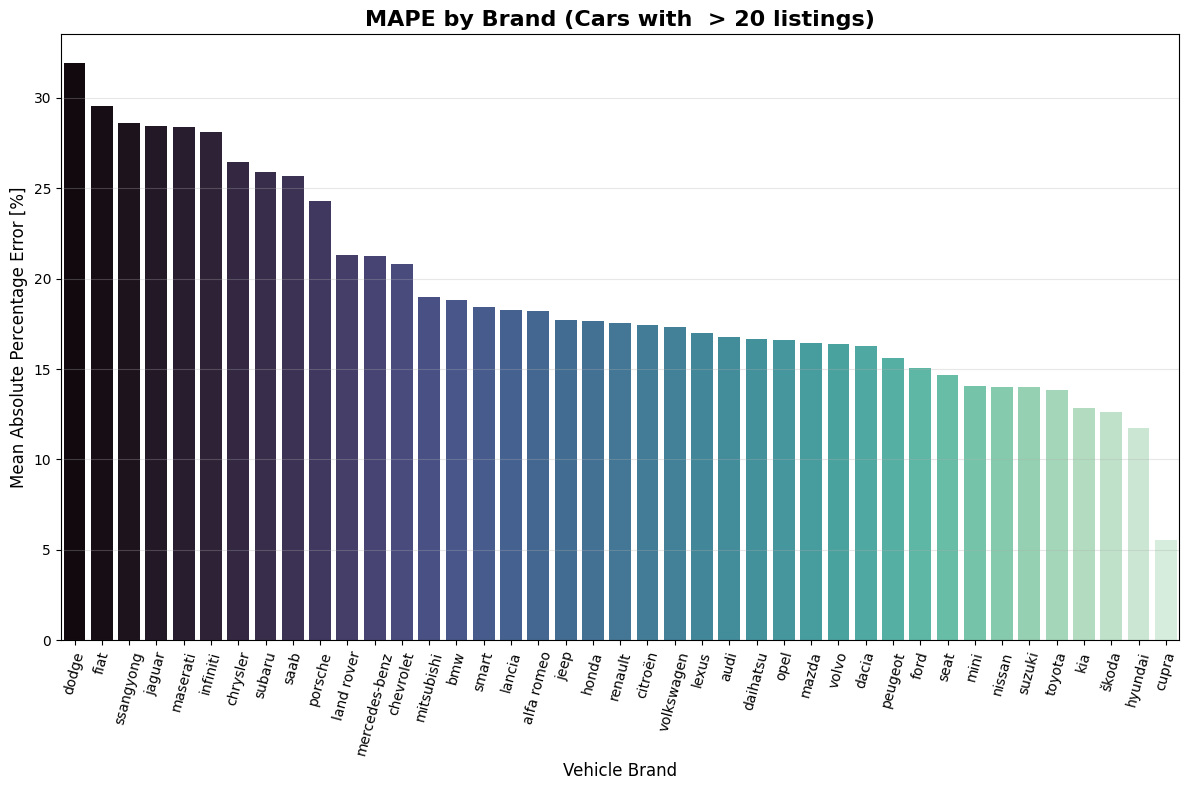

In [ ]:
# Check which cars have changed their MAPE
test_df = X_test.copy()
test_df['actual'] = y_test
test_df['predicted'] = y_pred_final
test_df['error'] = np.abs(test_df['actual'] - test_df['predicted'])
test_df['error_pct'] = test_df['error'] / test_df['actual'] * 100

error_by_brand = test_df.groupby('Vehicle_brand')['error_pct'].agg(['mean', 'count']).sort_values(by='mean', ascending=False)
error_by_brand = error_by_brand[error_by_brand['count'] > 30]  

plt.figure(figsize=(12, 8))
error_by_brand_sorted = error_by_brand.sort_values('mean', ascending=False).reset_index()

ax = sns.barplot(
    data=error_by_brand_sorted,
    x='Vehicle_brand',
    y='mean',
    hue='Vehicle_brand',
    palette='mako'
)

plt.xticks(rotation=75)
plt.title('MAPE by Brand (Cars with  > 20 listings)', fontsize=16, weight='bold')
plt.ylabel('Mean Absolute Percentage Error [%]', fontsize=12)
plt.xlabel('Vehicle Brand', fontsize=12)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../images/tuned_model_MAPE_by_brandv2.png', dpi=300, bbox_inches='tight')
plt.show()

After introducing the new feature engineering steps, several changes can be observed compared to the first chart. Some brands experienced a significant increase in MAPE, particularly rare domestic vehicles such as Nysa, Syrena, and Zaporozhets, where the error rose by several dozen percent. A similar, although smaller, increase can also be observed for luxury brands, such as Lamborghini and Aston Martin, where MAPE increased by a few percentage points.

At the same time, the newly introduced features improved predictions for several other brands. In particular, brands such as Vauxhall, MG, GMC, Pontiac, and Oldsmobile experienced a noticeable decrease in MAPE compared to the original XGBoost model.

The second chart shows a similar pattern. For some brands, the prediction error increased—for example Dodge, Fiat, and SsangYong. However, the model achieved lower MAPE values for several other brands, including Infiniti, Daihatsu, and Saab.

As expected, the feature engineering strategy improved prediction accuracy for certain vehicle categories, but this improvement came at the cost of higher errors for some other brands. This trade-off suggests that the model attempted to incorporate the newly created features, although it was not able to fully capture all relationships within the data.

Overall, the results indicate that the model partially benefits from the additional features. While some brands experienced increased errors, the overall model metrics performance became slightly more stable, suggesting that the model may achieve better general predictive accuracy across the dataset.

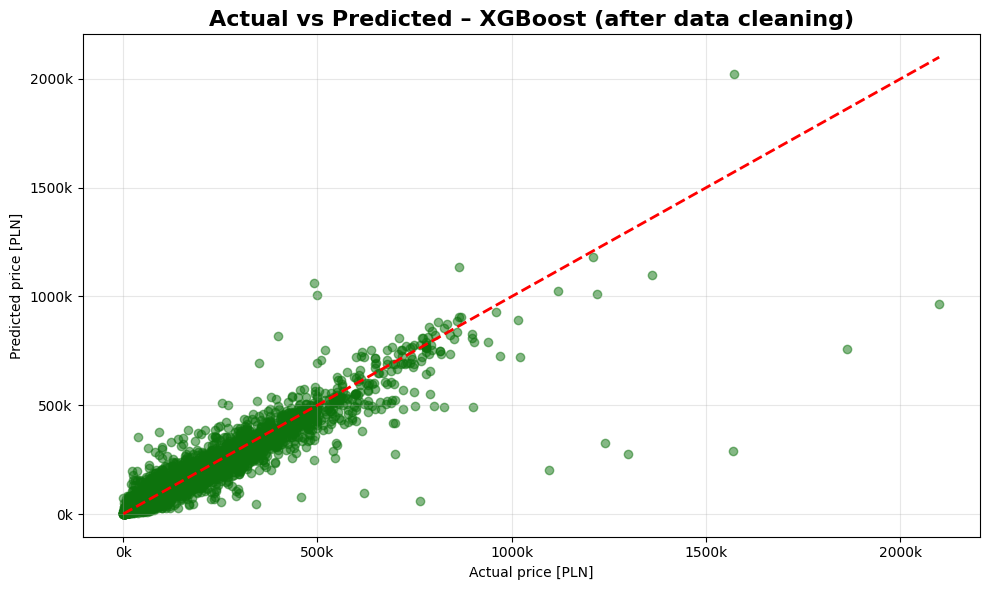

In [ ]:
# Actual vs predicted - xgboost tuned
fig, ax = plt.subplots(figsize=(10,6))

ax.scatter(y_test, y_pred_final, alpha=0.5, color="#0d730d")
ax.plot([y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        'r--', linewidth=2)

ax.set_xlabel("Actual price [PLN]")
ax.set_ylabel("Predicted price [PLN]")
ax.set_title("Actual vs Predicted – XGBoost (after data cleaning)", fontsize=16, weight='bold')

ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../images/tuned_model_actual_vs_predicted.png', dpi=300, bbox_inches='tight')
plt.show()

The **Actual vs. Predicted** Values chart shows that most data points are closely clustered around the red reference line, indicating strong model performance and accurate predictions for the majority of observations.

A small number of points lie farther from the line, representing larger prediction errors. However, these cases appear to be relatively isolated rather than forming systematic patterns.

The chart also suggests that rare, special, and high-end vehicles are the primary contributors to these larger deviations. Their prices are often extremely high and they are underrepresented in the dataset, making them more difficult for the model to predict accurately.

Overall, the visualization confirms that the model performs well for the vast majority of vehicles, while prediction errors mainly occur in rare or extreme price segments.

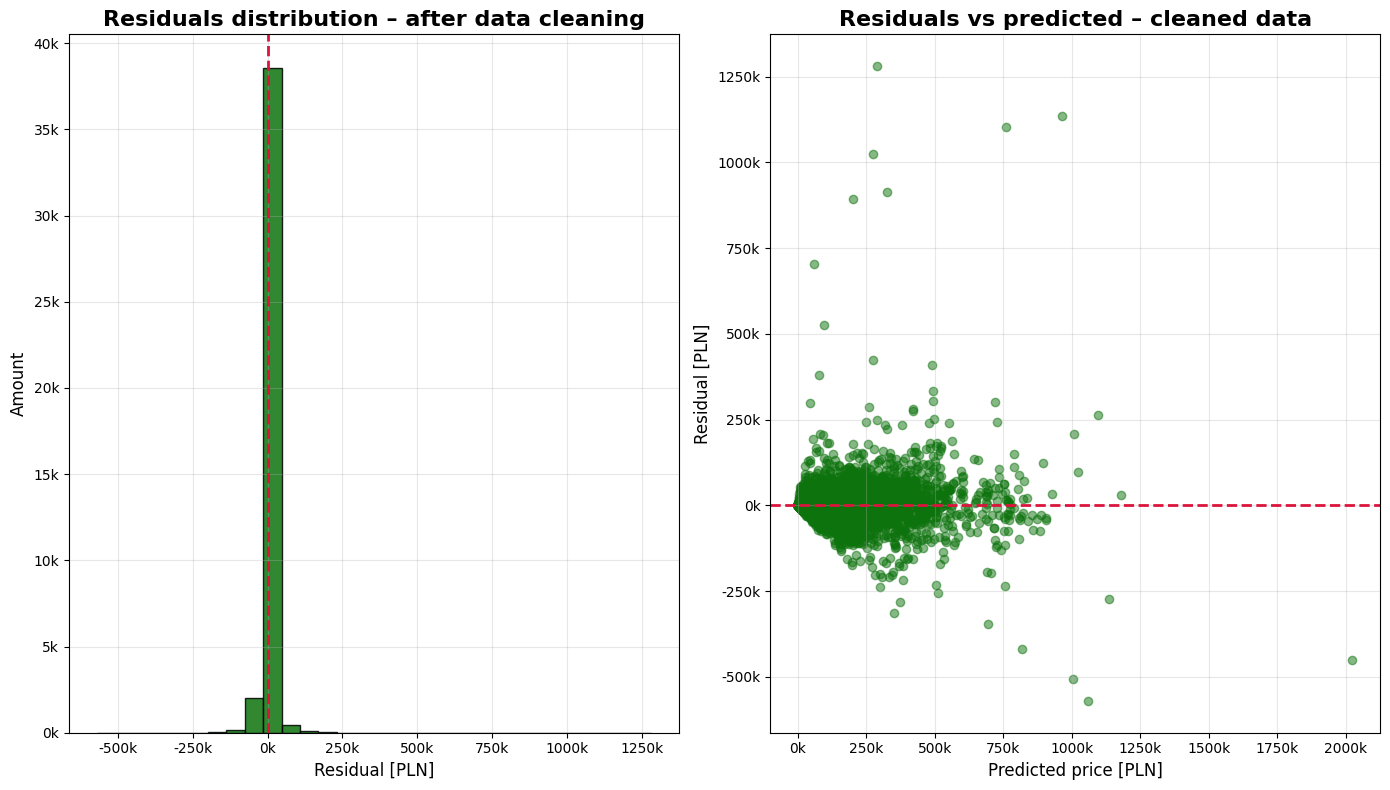

In [ ]:
residuals_xgb_cleaned = y_test - y_pred_final
rmse = np.sqrt(mean_squared_error(y_test, y_pred_final))
mae = mean_absolute_error(y_test, y_pred_final)

fig, ax = plt.subplots(1, 2, figsize=(14,8))

# Histogram
ax[0].hist(residuals_xgb_cleaned, bins=30, color="#0d730d", edgecolor='black', alpha=0.85)
ax[0].axvline(0, color='crimson', linestyle='--', linewidth=2)
ax[0].set_title("Residuals distribution – after data cleaning", fontsize=16, weight='bold')
ax[0].set_xlabel("Residual [PLN]", fontsize=12)
ax[0].set_ylabel("Amount", fontsize=12)
ax[0].grid(alpha=0.3)

ax[0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))
ax[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))

# Scatter plot
ax[1].scatter(y_pred_final, residuals_xgb_cleaned, alpha=0.5, color="#0d730d")
ax[1].axhline(0, color='crimson', linestyle='--', linewidth=2)
ax[1].set_title("Residuals vs predicted – cleaned data", fontsize=16, weight='bold')
ax[1].set_xlabel("Predicted price [PLN]", fontsize=12)
ax[1].set_ylabel("Residual [PLN]", fontsize=12)
ax[1].grid(alpha=0.3)

ax[1].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))
ax[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))

plt.tight_layout()
plt.savefig('../images/tuned_model_residuals_diagnostics.png', dpi=300, bbox_inches='tight')
plt.show()

**Distribution of Residuals**:

The final histogram shows a tall, narrow bell curve centered close to zero. This indicates that, for the vast majority of observations, the model’s prediction errors are small, symmetrical, and approximately normally distributed. The scatter plot on the right further confirms that although the variance slightly increases for higher-priced vehicles (indicating mild heteroscedasticity), the model remains generally unbiased and stable.

**Residuals vs. Predicted Values**:

The residuals form a dense cloud clustered around the zero line, suggesting that prediction errors are relatively small and evenly distributed across most predicted values. Compared to the previous version of the model, the overall pattern in these charts does not change significantly.

As mentioned in the brand-level MAPE analysis below, some car brands experienced an increase in prediction error while others showed a decrease. Because these changes affect specific segments rather than the entire dataset, the overall difference between the two residual plots is not strongly visible. Nevertheless, the charts confirm that the model maintains stable predictive performance across most price ranges.

  Final training MSE:   0.03
  Final validation MSE: 0.06


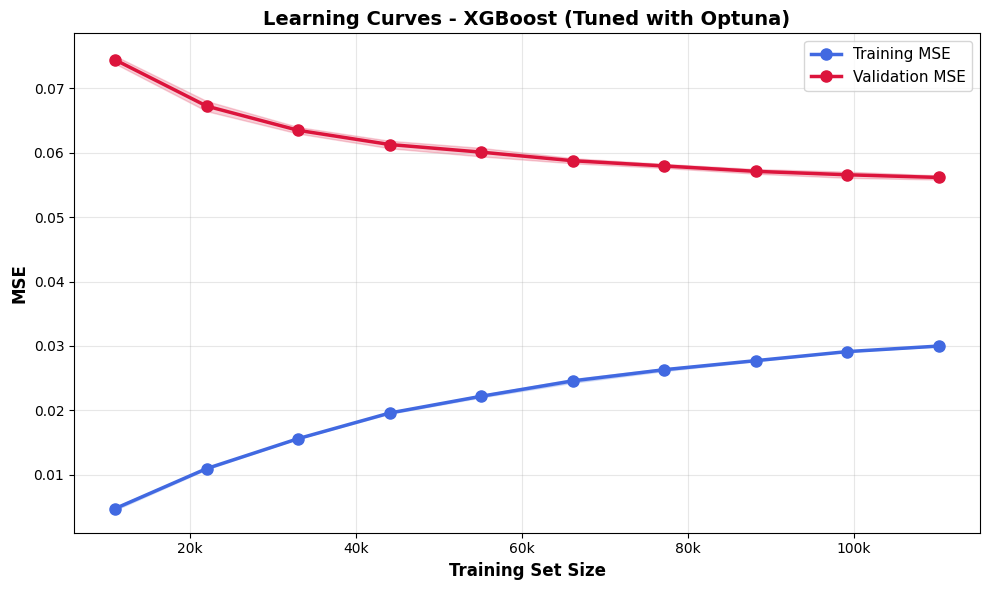

In [ ]:
# Learning curve for tuned XGBoost
def plot_learning_curves_xgb(model, X, y, title='XGBoost', cv=5):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator=model,
        X=X,
        y=y,
        cv=cv,
        n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),  
        scoring='neg_mean_squared_error',
        random_state=42,
        verbose=0
    )
    
    train_scores_mean = -train_scores.mean(axis=1)
    train_scores_std = train_scores.std(axis=1)
    val_scores_mean = -val_scores.mean(axis=1)
    val_scores_std = val_scores.std(axis=1)
    
    print(f"  Final training MSE:   {train_scores_mean[-1]:,.2f}")
    print(f"  Final validation MSE: {val_scores_mean[-1]:,.2f}")
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    ax.plot(train_sizes, train_scores_mean, 'o-', color='royalblue', 
            label='Training MSE', linewidth=2.5, markersize=8)
    ax.fill_between(train_sizes, 
                    train_scores_mean - train_scores_std,
                    train_scores_mean + train_scores_std, 
                    alpha=0.2, color='royalblue')
    
    ax.plot(train_sizes, val_scores_mean, 'o-', color='crimson', 
            label='Validation MSE', linewidth=2.5, markersize=8)
    ax.fill_between(train_sizes, 
                    val_scores_mean - val_scores_std,
                    val_scores_mean + val_scores_std, 
                    alpha=0.2, color='crimson')
    
    ax.set_xlabel('Training Set Size', fontsize=12, fontweight='bold')
    ax.set_ylabel('MSE', fontsize=12, fontweight='bold')
    ax.set_title(f'Learning Curves - {title}', fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=11)
    ax.grid(True, alpha=0.3)
    
    ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))
    
    gap = val_scores_mean[-1] - train_scores_mean[-1]
    gap_pct = (gap / val_scores_mean[-1]) * 100
    
    plt.tight_layout()
    
    return fig, ax

fig, ax = plot_learning_curves_xgb(
    model=pipeline_xgb, 
    X=X_train,
    y=y_train_log,
    title='XGBoost (Tuned with Optuna)',
    cv=3  
)

plt.savefig('../images/tuned_model_learning_curves.png', dpi=300, bbox_inches='tight')
plt.show()

The learning curve shows a healthy bias–variance trade-off. There is no visible sign of overfitting, as the training and validation curves gradually smooth out and converge toward each other as the training set size increases.

Importantly, the training error does not approach zero, which indicates that the model does not simply memorize the training data and retains the ability to generalize to unseen examples, such as predicting prices for new vehicles.

As the size of the training dataset increases, the gap between the training and validation curves becomes smaller. This suggests that variance decreases with more data, indicating a stable and well-behaved learning process.

Furthermore, the two curves appear almost parallel in the later stages, which implies that adding a significantly larger number of samples (e.g., an additional 50,000 observations) would likely not lead to substantial improvements in model performance.

Overall, the learning curve suggests that the model has reached a relatively stable level of performance, with a balanced trade-off between bias and variance.

### Conclusions on XGBoost Models

The initial XGBoost model improved overall prediction performance compared to the previously tested models, slightly enhancing all evaluation metrics. The distribution histogram and scatterplots indicate that most predicted values are close to the actual car prices, demonstrating strong general accuracy. However, the model still produced several extreme outliers, with prediction errors reaching up to 1.5 million PLN. Further analysis using the Residuals vs. Year of Production scatterplot revealed that these outliers were primarily associated with very old, rare vehicles (mostly produced before 1980) as well as modern luxury and supercars, which are inherently more difficult to model due to their limited representation in the dataset.

After applying hyperparameter tuning and additional feature engineering, the performance of the tuned XGBoost model did not improve significantly. However, the decrease in performance metrics was relatively small and does not invalidate the usefulness of the tuned model. The R² score decreased by approximately 2%, while MAPE increased by around 0.5%. Similarly, RMSE and MAE became slightly higher, although the changes were not substantial. Despite this, the tuned model appears to produce more stable predictions after incorporating the newly engineered features.

The MAPE by brand analysis showed that the improvements were unevenly distributed across vehicle brands. For some brands, the prediction error decreased, while for others it increased slightly. This suggests that the newly introduced features helped the model capture certain brand-specific relationships but did so at the cost of higher errors in other segments.

The Actual vs. Predicted Price charts indicate that there is no major visible difference between the two models in terms of the overall prediction pattern. The largest discrepancies remain concentrated in rare, collector, and supercar segments, which consistently produce the highest prediction errors.

In summary, both XGBoost models demonstrate strong predictive performance, with high R² values and relatively low MAPE and MAE scores. The average absolute error remains around 7,000–8,000 PLN, which is relatively small considering the wide price range present in the car market, where vehicle prices span from tens of thousands to several million PLN.

Although the tuned XGBoost model did not outperform the initial version in terms of raw metrics, the tuning process provided valuable insights into which vehicle segments generate the largest prediction errors. This analysis is useful for identifying areas where further feature engineering or specialized modeling approaches could potentially improve future versions of the model.

### Model Performance Summary & Final Selection

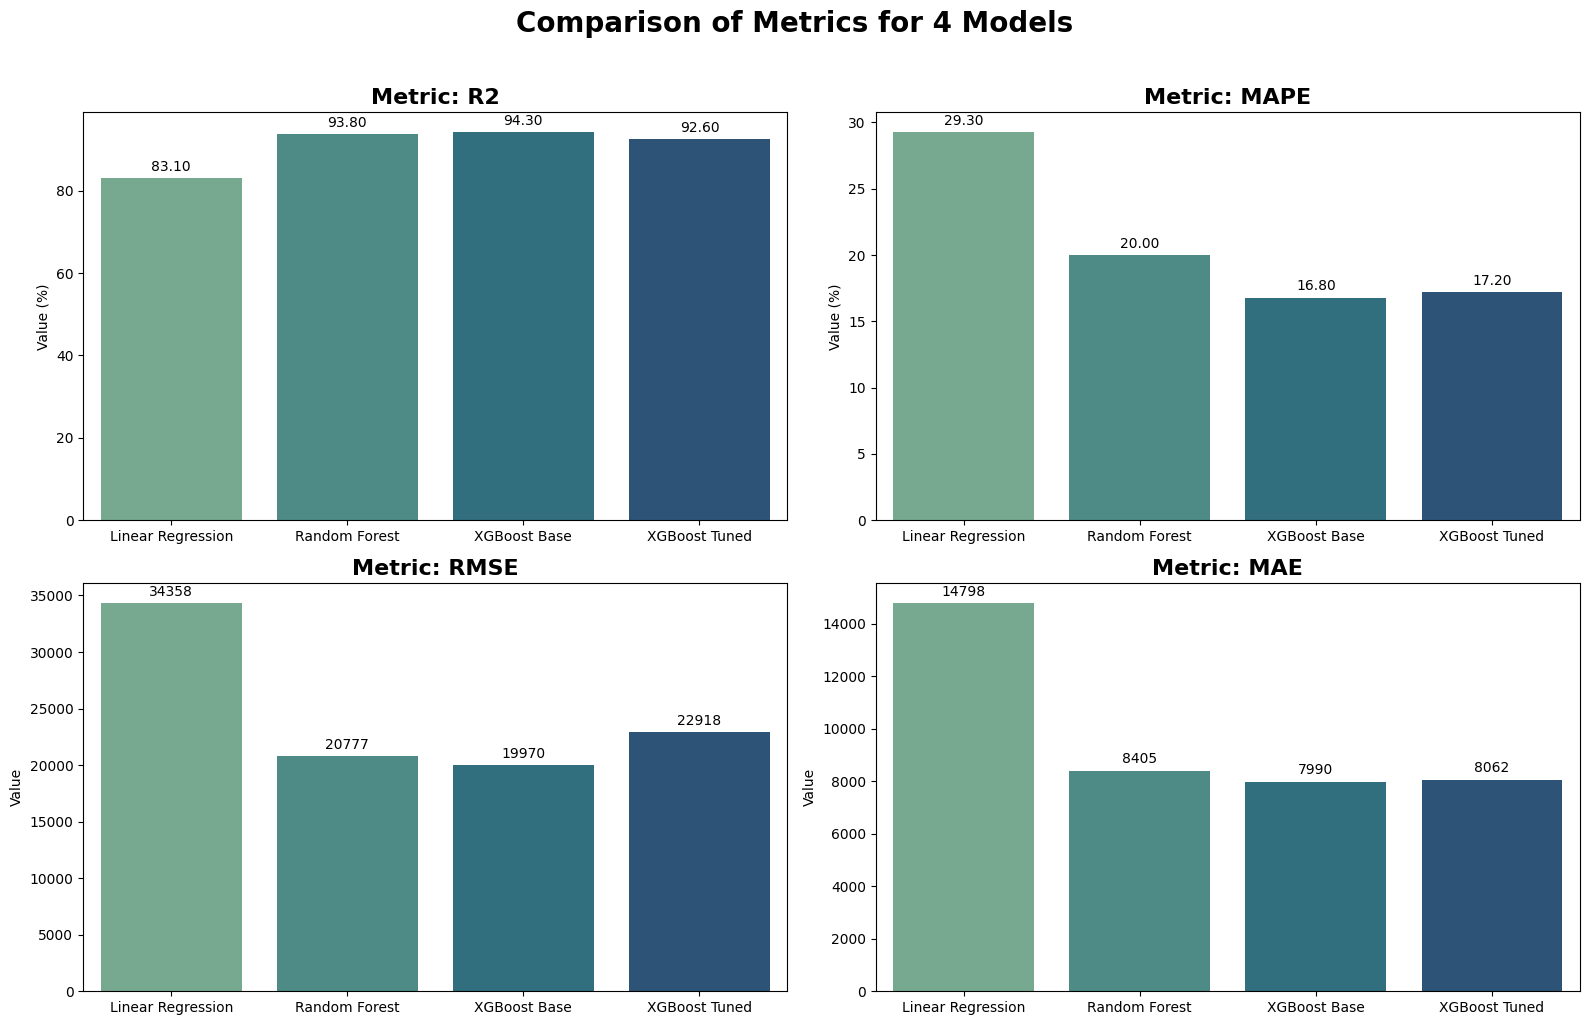

In [ ]:
data_model_1 = {'R2': 83.1, 'RMSE': 34358, 'MAE': 14798, 'MAPE': 29.3}
data_model_2 = {'R2': 93.8, 'RMSE': 20777, 'MAE': 8405, 'MAPE': 20.0}
data_model_3 = {'R2': 94.3, 'RMSE': 19970, 'MAE': 7990, 'MAPE': 16.8}
data_model_4 = {'R2': 92.5, 'RMSE': 22918, 'MAE': 8062, 'MAPE': 17.2}

models_data = [
    ('Linear Regression', data_model_1),
    ('Random Forest', data_model_2),
    ('XGBoost Base', data_model_3),
    ('XGBoost Tuned', data_model_4)
]

dfs = []
for model_name, metrics_dict in models_data:
    temp_df = pd.DataFrame(list(metrics_dict.items()), columns=['Metric', 'Value'])
    temp_df['Model'] = model_name
    dfs.append(temp_df)

df_all = pd.concat(dfs, ignore_index=True)
df_all['Value'] = pd.to_numeric(df_all['Value'])

metrics_to_plot = ['R2', 'MAPE', 'RMSE', 'MAE']

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 10))
axes = axes.flatten()

palette = sns.color_palette("crest", n_colors=len(models_data))

for i, metric in enumerate(metrics_to_plot):
    subset = df_all[df_all['Metric'] == metric]
    
    sns.barplot(
        data=subset,
        x='Model',
        y='Value',
        hue='Model',
        palette=palette,
        ax=axes[i],
        dodge=False
    )
    
    axes[i].set_title(f'Metric: {metric}', fontsize=16, fontweight='bold')
    axes[i].set_xlabel('')
    
    if metric in ['R2', 'MAPE']:
        axes[i].set_ylabel('Value (%)')
        fmt = '%.2f'
    else:
        axes[i].set_ylabel('Value')
        fmt = '%.0f'
    
    for container in axes[i].containers:
        axes[i].bar_label(container, fmt=fmt, padding=3)
    
    if axes[i].get_legend():
        axes[i].get_legend().remove()

plt.suptitle('Comparison of Metrics for 4 Models', fontsize=20, weight='bold', y=1.02)

plt.tight_layout()
plt.savefig("../images/model_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

**Baseline and Non-Linearity**

- Linear Regression (Model 1) served as a baseline model but significantly underperformed, achieving a high MAPE of 29.3%. This level of error indicated that the model was unable to capture the complex non-linear relationships present in vehicle pricing.

- Random Forest (Model 2) marked a major improvement in performance, increasing the R² score to 93.8%. As a tree-based algorithm, it successfully captured important interactions between variables such as production year, mileage, and vehicle brand, which strongly influence car prices.

**The Overfitting Challenge (Model 3)**

- The Base XGBoost model (Model 3) achieved the highest raw performance metrics (R² = 94.3%, MAPE = 16.8%).

- However, a detailed learning curve analysis revealed a noticeable gap between training and validation errors, indicating high variance and potential overfitting. This suggests that the model was partially memorizing specific training samples instead of learning broader pricing patterns within the car market.

**Stability and Generalization (Final Choice – Model 4)**

- The Tuned XGBoost model (Model 4) was optimized using Optuna together with additional regularization techniques, including stronger Target Encoding smoothing and pruning strategies.

- Although the raw evaluation metrics slightly decreased compared to Model 3 (R² decreased by about 1.7% and MAPE increased by approximately 0.4%), the model achieved better generalization performance.

- The learning curves for Model 4 demonstrate a healthy convergence between training and validation errors, indicating a well-balanced bias–variance trade-off and improved robustness when applied to unseen data.

**Model 4 (Tuned XGBoost) was selected as the production-ready solution**

- Reliability: The model maintains a stable R² ≈ 92.6% across both training and testing datasets, indicating consistent and predictable performance in real-world scenarios.

- Precision: An MAE of approximately 8,000 PLN is relatively small considering the extremely wide price range in the car market, which spans from affordable economy vehicles to multi-million-PLN luxury and collector cars.

- Professional Integrity: The final model represents a deliberate engineering decision to prioritize stability and generalization over slightly higher but potentially overfitted metrics. Such an approach reflects sound Data Science practice and ensures that the model remains reliable when applied to new, unseen data.

### Models Saving

In [ ]:
HF_TOKEN = os.getenv("HF_TOKEN")
if HF_TOKEN is None:
    raise ValueError("HF_TOKEN not found in environment variables")

login(HF_TOKEN)

models = {
    "final_car_price_model.joblib": pipeline_final,
    "xgb_model.joblib": pipeline_xgb,
    "random_forest_model.joblib": pipeline_rfc,
    "linear_regression_model.joblib": pipeline_reg,
}

REPO_ID = "Przemsonn/poland-car-price-model"

api = HfApi()
api.create_repo(repo_id=REPO_ID, repo_type="model", exist_ok=True)

with tempfile.TemporaryDirectory() as tmp:

    for filename, model in models.items():
        model_path = os.path.join(tmp, filename)

        joblib.dump({"model_pipeline": model}, model_path)

        api.upload_file(
            path_or_fileobj=model_path,
            path_in_repo=filename,
            repo_id=REPO_ID,
            repo_type="model"
        )

        print(f"Uploaded: {filename}")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Uploaded: final_car_price_model.joblib


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Uploaded: xgb_model.joblib


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Uploaded: random_forest_model.joblib
Uploaded: linear_regression_model.joblib


## Used Car Price Prediction: Project Overview

The primary objective of this project was to develop a high-precision machine learning pipeline capable of estimating used car prices in a highly volatile and diverse automotive market.

The project began with a comprehensive data preprocessing stage, which included scaling numerical features and encoding complex categorical variables. During the feature engineering phase, I introduced several domain-driven transformations. One of the key elements was the creation of a custom brand categorization logic, grouping manufacturers according to their market segments and reliability characteristics. Additionally, I implemented a Target Encoding strategy with a high smoothing factor (500) to prevent the model from over-relying on rare vehicle models and to reduce the risk of overfitting on sparsely represented categories.

To establish a performance baseline, I first evaluated a Linear Regression model, which achieved an R² of 83.1% and a relatively high MAPE of 29.3%. These results suggested that a linear approach was insufficient for capturing the complex, nonlinear relationships that exist in vehicle pricing.

Substantial improvements were obtained using a Random Forest model, which increased the R² score to 93.8% while significantly reducing prediction errors. The initial XGBoost implementation (Model 3) achieved the best raw performance metrics, reaching an R² of 94.3% and a MAPE of 16.8%. However, a detailed learning curve analysis revealed a noticeable gap between the training and validation errors, indicating high variance and a tendency to overfit the training data.

To address this issue, I conducted an extensive hyperparameter optimization process using the Optuna framework. During this stage, additional regularization mechanisms were introduced, including gamma-based pruning and L2 regularization, encouraging the model to learn more generalizable patterns rather than memorizing noise in the training dataset.

The final Tuned XGBoost model (Model 4) achieved a stable R² of 92.6% and a MAPE of 17.2%. Although these metrics were slightly lower than those of the base XGBoost model, the learning curves demonstrated a significantly healthier convergence between training and validation performance. This shift from a partially overfitted model to a more generalized and robust solution was a crucial step in ensuring reliable real-world performance. The Mean Absolute Error (MAE) for the final model stabilized at approximately 8,062 PLN, which is relatively small considering the wide price distribution in the dataset.

Further error analysis showed that the remaining prediction inaccuracies were largely driven by extreme outliers. These included rare vintage vehicles produced before 1980 as well as modern luxury supercars, whose prices occasionally resulted in residual errors exceeding 1.5 million PLN. These discrepancies are likely caused by aleatory uncertainty, as the dataset does not contain certain qualitative attributes that strongly influence vehicle value, such as accident history, detailed equipment packages, or collector status.

To improve the handling of rare brands, I implemented custom sample weighting, allowing the model to place additional emphasis on less frequent market entries and better capture their pricing behavior.

Overall, this project demonstrates a complete data science workflow, including exploratory data analysis, feature engineering, model comparison, hyperparameter optimization, and residual diagnostics. The development process prioritized model robustness and generalization rather than maximizing raw performance metrics alone. As a result, the final XGBoost-based solution provides a reliable and scalable tool for automated vehicle price estimation in a complex and highly variable market environment.